In [41]:
import pandas as pd
import re
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML


from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score


import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import ParameterGrid

import torch
import torch.nn as nn
from skorch.callbacks import EarlyStopping
from skorch import NeuralNetRegressor

import optuna

# Project Data Foundation and Pipeline Overview
This section documents the data sources, the structure of the ingested files, and the logic used to merge financial transactions with legislative activity for the study period 2021–2026.

## 1. Data Sources and Platforms
The dataset is constructed by synthesizing information from two primary external platforms:

Quiver Quantitative: A financial data platform used to retrieve high-frequency Congressional trading data. This source provides transaction records including stock tickers, transaction dates (Traded/Filed), and lawmaker names.

LegiScan: An API-based legislative tracking platform used to retrieve the full legislative history of the 117th, 118th, and 119th U.S. Congresses. This provides metadata for bills, their sponsors, and unique legislative identifiers.

## 2. Data Inventory
The pipeline integrates several local files into a unified relational database:

Trading Records: The master file congress-trading-all.xlsx containing the financial history of individual lawmakers.

Legislator Records: The people117.csv, people118.csv, and people119.csv files, which contain unique lawmaker IDs and political roles.

Sponsorship Records: The sponsors117.csv, sponsors118.csv, and sponsors119.csv files, which act as the bridge between legislators and the bills they introduced or co-sponsored.

Bill Details: The bills117.csv, bills118.csv, and bills119.csv files, which contain the official titles and descriptions of all proposed legislation.

## 3. Pipeline Methodology and Code Logic
To ensure data integrity and computational efficiency, the Python pipeline follows a specific logical flow:

### A. Name-Based Identity Bridging
Because the legislative data and the financial data often use different identification systems, a custom name-cleaning algorithm was developed. This function standardizes names from both sources (e.g., handles "Moore, Tim" vs "Tim Moore") to create a matching key based on standardized last names. This allows the code to link a stock trade to a specific legislator's unique ID.

### B. Temporal Filtering (2021–2026)
The trading data is filtered at the point of ingestion to restrict the analysis to the study window starting January 1, 2021. By removing irrelevant data before performing joins, the code maintains high speed and reduces memory usage.

### C. Relational Data Merging
The pipeline performs a series of optimized joins to connect four separate data levels:

The Trade (from Quiver)

The Lawmaker (via the name match)

The Sponsorship (via the unique legislator ID)

The Bill Details (via the bill ID).

## 4. Technical Implementation
The pipeline is built using the Pandas library in Python. It utilizes specific engines like openpyxl for Excel ingestion and latin1 encoding for CSV files to ensure that special characters and financial symbols are preserved. Performance is optimized through vectorization, allowing the system to scan hundreds of thousands of legislative and financial records simultaneously in seconds.

In [42]:
df = pd.read_excel('congress-trading-all.xlsx')

# HELPER: FAST NAME CLEANING

def clean_last_name(name_series):
    """
    Standardizes names for matching. 
    Handles 'Last, First' or 'First Last' by extracting the primary last name.
    """
    # Convert to lowercase and string
    s = name_series.astype(str).str.lower().str.strip()
    # If the format is 'Last, First', take the part before the comma
    s = s.str.split(',').str[0].str.strip()
    # Otherwise, take the last word (fallback for 'First Last' format)
    s = s.apply(lambda x: x.split()[-1] if ' ' in x and ',' not in x else x)
    # Remove non-alphabetical characters
    return s.str.replace(r'[^a-z]', '', regex=True)

# PREPARE THE DATA

# Filter your Excel data for the study period immediately to save memory
df['Traded'] = pd.to_datetime(df['Traded'], errors='coerce')
df_filtered = df[df['Traded'] >= '2021-01-01'].copy()
df_filtered['match_key'] = clean_last_name(df_filtered['Name'])

# Load LegiScan people (117, 118, 119)
people_files = ['people117.csv', 'people118.csv', 'people119.csv']
ls_people = pd.concat([pd.read_csv(f) for f in people_files if os.path.exists(f)])

# Use the columns you identified: 'last_name' and 'people_id'
ls_people['match_key'] = clean_last_name(ls_people['last_name'])
ls_people = ls_people.drop_duplicates(subset=['people_id'])

# THE BRIDGE 

# Merge trades with people to get the people_id
df_study = pd.merge(
    df_filtered,
    ls_people[['people_id', 'match_key', 'party', 'role']],
    on='match_key',
    how='inner'
)

print(f"Success! Processed {len(df_study)} trades for the 2021-2026 period.")
print("You now have 'people_id' in your dataframe to link with sponsors/bills.")

# THE CUSTOM FILTERING (Example)

# Now we can search for a specific company and see the lawmaker's bills
# example_nvda = df_study[df_study['Ticker'] == 'NVDA']
display(df_study[['Name', 'Ticker', 'Traded', 'people_id']].head())

Success! Processed 57363 trades for the 2021-2026 period.
You now have 'people_id' in your dataframe to link with sponsors/bills.


,Name,Ticker,Traded,people_id
0,Tim Moore,COIN,2026-02-18,9095
1,Tim Moore,COIN,2026-02-18,21922
2,Tim Moore,COIN,2026-02-18,21973
3,Tim Moore,COIN,2026-02-18,25916
4,Tim Moore,COIN,2026-02-18,25921


### Industry Sector Definition
We define four key industrial sectors and their associated legislative keywords. These keywords are used to scan bill titles for relevance to a politician's stock portfolio.

In [43]:
# Updated configuration with expanded keywords for better temporal coverage (2021-2026)
sector_keywords = {
    'Technology/AI': [
        'semiconductor', 'chip', 'artificial intelligence', 'ai', 'data', 
        'software', 'big tech', 'telecommunications', 'quantum', 'cybersecurity'
    ],
    'Energy/Climate': [
        'oil', 'gas', 'fossil', 'renewable', 'carbon', 'climate', 'energy', 
        'petroleum', 'greenhouse', 'electric vehicle', 'ev', 'grid', 'utility'
    ],
    'Finance/Crypto': [
        'banking', 'financial', 'crypto', 'currency', 'digital asset', 
        'securities', 'wall street', 'insurance', 'tax', 'monetary', 
        'federal reserve', 'lending', 'credit', 'consumer protection', 'inflation'
    ],
    'Healthcare/Pharma': [
        'pharmaceutical', 'drug', 'vaccine', 'medicare', 'health', 
        'biotech', 'medical device', 'fda', 'patent', 'clinical'
    ]
}

### Optimized Legislative Data Extraction

To prevent memory overflow, we process the LegiScan datasets (Sessions 117, 118, and 119) using chunking. We only retain bills that match our predefined keywords and were sponsored by lawmakers present in our trading dataset.

In [44]:
relevant_leg_data = []
all_pattern = '|'.join([kw for sector in sector_keywords.values() for kw in sector])
active_ids = set(df_study['people_id'].unique())

for s in ['117', '118', '119']:
    b_file, s_file = f'bills{s}.csv', f'sponsors{s}.csv'
    if os.path.exists(b_file) and os.path.exists(s_file):
        # Load sponsors and filter by active lawmakers
        spons = pd.read_csv(s_file, usecols=['people_id', 'bill_id'])
        spons = spons[spons['people_id'].isin(active_ids)]
        
        # Stream bill data in chunks to handle large file sizes
        for chunk in pd.read_csv(b_file, usecols=['bill_id', 'title'], chunksize=10000):
            filtered = chunk[
                (chunk['bill_id'].isin(spons['bill_id'])) & 
                (chunk['title'].str.contains(all_pattern, case=False, na=False))
            ].copy()
            
            if not filtered.empty:
                relevant_leg_data.append(pd.merge(filtered, spons, on='bill_id'))

df_legislative_hits = pd.concat(relevant_leg_data).drop_duplicates()

### Data Integration and Multi-Stage Filtering
The initial merge between trading data and legislative hits creates a large "Cartesian Product." We apply a strict Temporal Alignment Filter to ensure that a trade is only matched with a bill from the same Congressional session.

In [45]:
def filter_by_strict_window(df):
    """
    Filters rows to ensure the trade date matches the corresponding 
    Congressional Session of the bill.
    """
    df['Traded'] = pd.to_datetime(df['Traded'], errors='coerce')
    df['bill_id_str'] = df['bill_id'].astype(str)
    
    # Define session masks (117: 2021-22, 118: 2023-24, 119: 2025-26)
    mask_117 = (df['Traded'].dt.year.isin([2021, 2022])) & (df['bill_id_str'].str.contains('117'))
    mask_118 = (df['Traded'].dt.year.isin([2023, 2024])) & (df['bill_id_str'].str.contains('118'))
    mask_119 = (df['Traded'].dt.year.isin([2025, 2026])) & (df['bill_id_str'].str.contains('119'))
    
    return df[mask_117 | mask_118 | mask_119].copy()

# Execute the merge and apply the temporal filter
df_refined = pd.merge(df_study, df_legislative_hits, on='people_id', how='inner')
df_precision = filter_by_strict_window(df_refined)

# Final cleanup: Remove duplicates and unassigned sectors
df_precision = df_precision.drop_duplicates(subset=['Name', 'Ticker', 'Traded', 'bill_id'])

### Sector Classification
We categorize each identified collision into its specific industrial sector for further statistical analysis.

In [46]:
df_precision['detected_sector'] = "Unassigned"
for sector, keywords in sector_keywords.items():
    pat = '|'.join(keywords)
    mask = df_precision['title'].str.contains(pat, case=False, na=False)
    df_precision.loc[mask, 'detected_sector'] = sector

# Save the finalized dataset
df_precision.to_csv('final_legislative_collisions.csv', index=False)

In [47]:
# Summary Statistics of the final dataset
print(f"--- Final Dataset Overview ---")
print(f"Total Rows: {len(df_precision)}")
print(f"Unique Lawmakers: {df_precision['Name'].nunique()}")
print(f"Unique Stocks: {df_precision['Ticker'].nunique()}")
print(f"Date Range: {df_precision['Traded'].min()} to {df_precision['Traded'].max()}")

# Logic Check: Temporal Distance
# Let's calculate the distance between trade and the session context
# (Ideally, we want to see that trades from 2021 stay in session 117, etc.)
df_precision['trade_year'] = df_precision['Traded'].dt.year
session_check = pd.crosstab(df_precision['trade_year'], df_precision['detected_sector'])
print("\n--- Distribution of Trades by Year and Sector ---")
print(session_check)

# Content Audit: Let's look at 10 random matches to see if they "make sense"
# This is a 'Sanity Check' for your methodology chapter.
print("\n--- Random Sample Audit (Check if Title matches Ticker context) ---")
sample_cols = ['Name', 'Ticker', 'detected_sector', 'title', 'Traded']
display(df_precision[sample_cols].sample(10))

# Integrity Check: Check for missing values in critical columns
print("\n--- Missing Value Report ---")
print(df_precision[['excess_return', 'people_id', 'bill_id', 'detected_sector']].isnull().sum())

--- Final Dataset Overview ---
Total Rows: 52062
Unique Lawmakers: 151
Unique Stocks: 2408
Date Range: 2021-01-04 00:00:00 to 2026-02-18 00:00:00

--- Distribution of Trades by Year and Sector ---
detected_sector  Energy/Climate  Finance/Crypto  Healthcare/Pharma  \
trade_year                                                           
2021                         51             370                689   
2022                         34             343                515   
2023                       3199            3430                162   
2024                        733            2676                125   
2025                       9926            4111               7164   
2026                       1275             600               1186   

detected_sector  Technology/AI  
trade_year                      
2021                      4434  
2022                      7008  
2023                       943  
2024                       327  
2025                      2675  
2026       

,Name,Ticker,detected_sector,title,Traded
4932613,Ro Khanna,BAC,Finance/Crypto,Virtual Currency Consumer Protection Act of 2021,2024-05-28
7174138,Ro Khanna,V,Finance/Crypto,Virtual Currency Consumer Protection Act of 2021,2023-05-04
2535622,Ro Khanna,MIAM,Healthcare/Pharma,Strengthen Kids’ Mental Health Now Act of 2022,2025-05-19
1524898,Ro Khanna,INTU,Healthcare/Pharma,Strengthen Kids’ Mental Health Now Act of 2022,2025-09-05
4695607,Ro Khanna,LEN-B,Finance/Crypto,Virtual Currency Consumer Protection Act of 2021,2024-07-01
17458667,Adam B. Schiff,ABBV,Technology/AI,Standing with Israel as it defends itself agai...,2021-12-13
12787943,Michael T. McCaul,AMZN,Technology/AI,ChiPACC Act of 2021,2025-04-11
2737541,Ro Khanna,SWKS,Healthcare/Pharma,Save Medicare Act,2025-04-23
3749934,Ro Khanna,TFC,Finance/Crypto,Presidential Tax Transparency Act,2025-01-17
12748343,Michael T. McCaul,LPLA,Technology/AI,ChiPACC Act of 2021,2025-06-27



--- Missing Value Report ---
excess_return      2423
people_id             0
bill_id               0
detected_sector       0
dtype: int64


In [48]:
# Remove rows where excess_return is NaN
df_final_clean = df_precision.dropna(subset=['excess_return']).copy()

# Final check of the counts
print(f"Rows before cleaning: {len(df_precision)}")
print(f"Rows after cleaning: {len(df_final_clean)}")
print(f"Data retained: {(len(df_final_clean)/len(df_precision))*100:.2f}%")

# Quick check: Is the sector distribution still balanced?
print("\n--- Cleaned Sector Distribution ---")
print(df_final_clean['detected_sector'].value_counts())

Rows before cleaning: 52062
Rows after cleaning: 49639
Data retained: 95.35%

--- Cleaned Sector Distribution ---
Energy/Climate       14751
Technology/AI        14455
Finance/Crypto       11043
Healthcare/Pharma     9390
Name: detected_sector, dtype: int64


# Results and Exploratory Data Analysis (EDA)
This section presents the empirical findings of the legislative-financial overlap. We analyze the performance of trades associated with specific legislative sectors and examine the temporal distribution of these "collisions."

## Performance Analysis by Legislative Sector
The following table summarizes the excess returns of Congressional trades filtered by their corresponding legislative sector.

In [49]:
# Grouping the final cleaned dataset by sector to evaluate performance metrics
# Metrics include Mean, Median, Standard Deviation, and Observation Count
performance_table = df_final_clean.groupby('detected_sector')['excess_return'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)

print("--- TABLE 1: EXCESS RETURNS BY LEGISLATIVE SECTOR ---")
display(performance_table)

--- TABLE 1: EXCESS RETURNS BY LEGISLATIVE SECTOR ---


,mean,median,std,count
detected_sector,,,,
Healthcare/Pharma,1.544482,-4.151930,70.079382,9390
Energy/Climate,-1.798543,-4.760927,63.273517,14751
Finance/Crypto,-6.102634,-9.973319,73.646289,11043
Technology/AI,-7.984661,-21.690958,136.026813,14455


## Interpretation of Performance Metrics:

### Healthcare/Pharma Dominance: 
The Healthcare sector stands out as the only category yielding a positive mean excess return (1.54%). This suggests that legislative events in this sector (e.g., FDA approvals, patent legislation) may provide a more actionable information advantage compared to other fields.

### Technology Volatility: 
While the Technology/AI sector shows the lowest mean return (-7.98%), it exhibits the highest Standard Deviation (136.0). This indicates extreme variance and "fat-tail" risks, where a few outlier trades likely deviate significantly from the average.

### Negative Medians: 
Across all sectors, the median excess return is negative. This is consistent with financial literature suggesting that the majority of individual trades underperform the broader market, even when legislative overlaps are present.

## Temporal Distribution: The "January Peak"
To understand when these overlaps occur, we visualize the collision density across the calendar year (2021–2026).

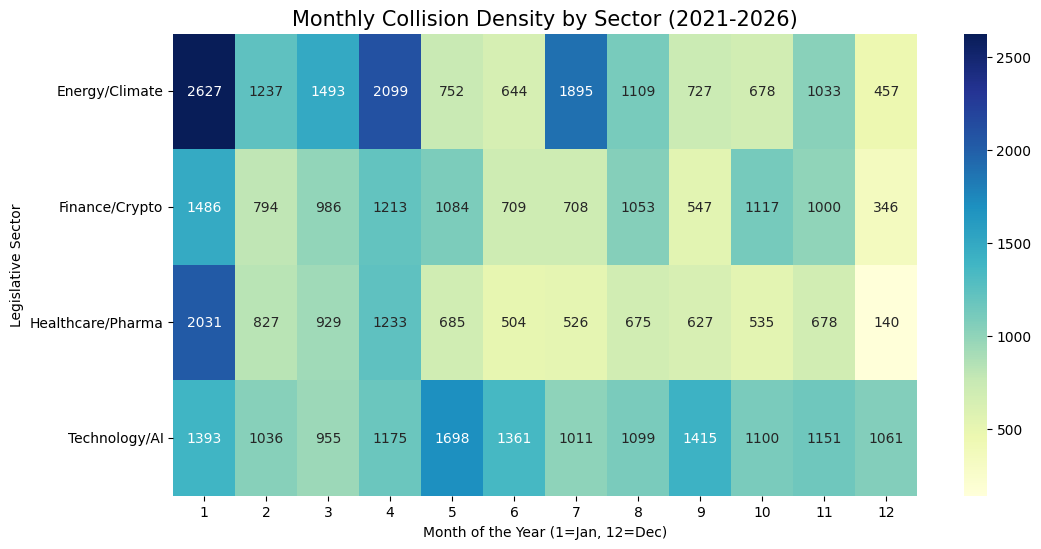

In [50]:
# Pivot data to count occurrences per sector and month
df_final_clean['month'] = df_final_clean['Traded'].dt.month
heatmap_data = df_final_clean.pivot_table(index='detected_sector', columns='month', values='excess_return', aggfunc='count')

# Visualizing the density of legislative-trade overlaps
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Monthly Collision Density by Sector (2021-2026)', fontsize=15)
plt.xlabel('Month of the Year (1=Jan, 12=Dec)')
plt.ylabel('Legislative Sector')
plt.show()

### The Session-Start Surge: 
There is a massive concentration of collisions in January. This likely reflects the start of new Congressional sessions where a high volume of bills are introduced, creating a surge in legislative "touchpoints" for lawmakers' existing or new stock positions.

### Energy and Climate Activity: 
The highest single density is found in Energy/Climate during January (2,627 observations). This matches the intense focus on green energy and climate policy updates early in the legislative calendar.

### Mid-Year Anomalies: 
Technology/AI shows a secondary peak in May, potentially coinciding with specific committee hearings or industry-specific regulatory discussions common in the second quarter.

# Top Lawmaker Concentration
We examine whether the data is driven by a broad group of legislators or concentrated among a few high-volume traders.

In [51]:
# Comparing the Top 5 most active lawmakers against the group average
top_5_names = df_final_clean['Name'].value_counts().head(5).index
top_trader_perf = df_final_clean[df_final_clean['Name'].isin(top_5_names)].groupby('Name')['excess_return'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
overall_avg = df_final_clean['excess_return'].mean()

print(f"--- TOP 5 TRADERS VS OVERALL GROUP AVERAGE ({overall_avg:.2f}%) ---")
display(top_trader_perf)

--- TOP 5 TRADERS VS OVERALL GROUP AVERAGE (-3.93%) ---


,mean,count
Name,,
Julie Johnson,4.787554,2986
Michael T. McCaul,-1.587944,2617
Ro Khanna,-2.553790,28164
Josh Gottheimer,-7.089553,3937
Daniel Goldman,-23.160412,2347


Parsing trade size intervals to midpoints...


/var/folders/68/q54y3w7n60n440k6wdcqqh240000gn/T/ipykernel_3564/1310564761.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='detected_sector', y='excess_return', data=df_plot, palette='Set2')


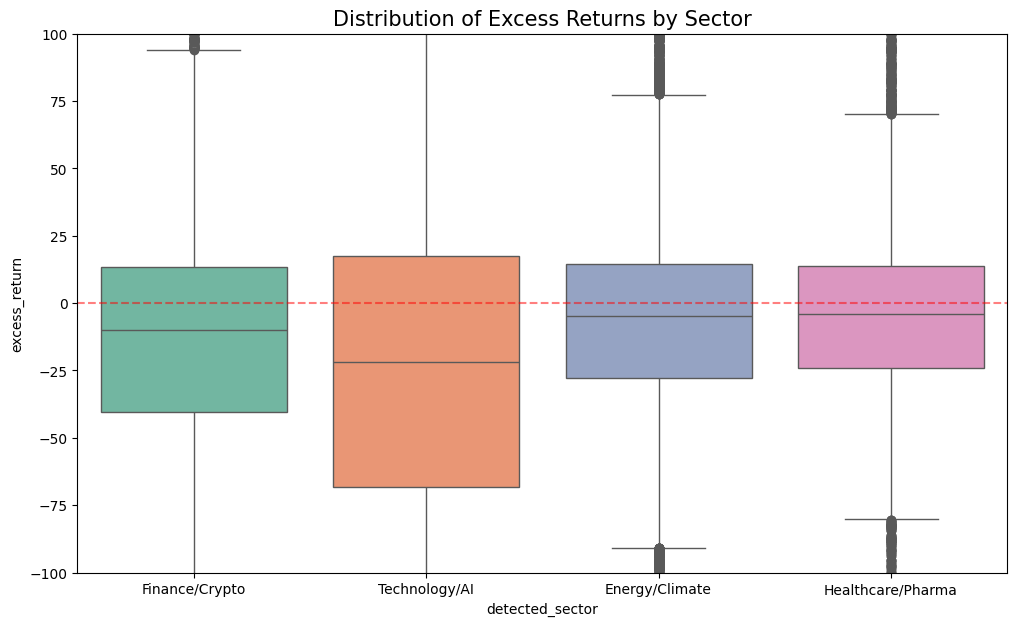

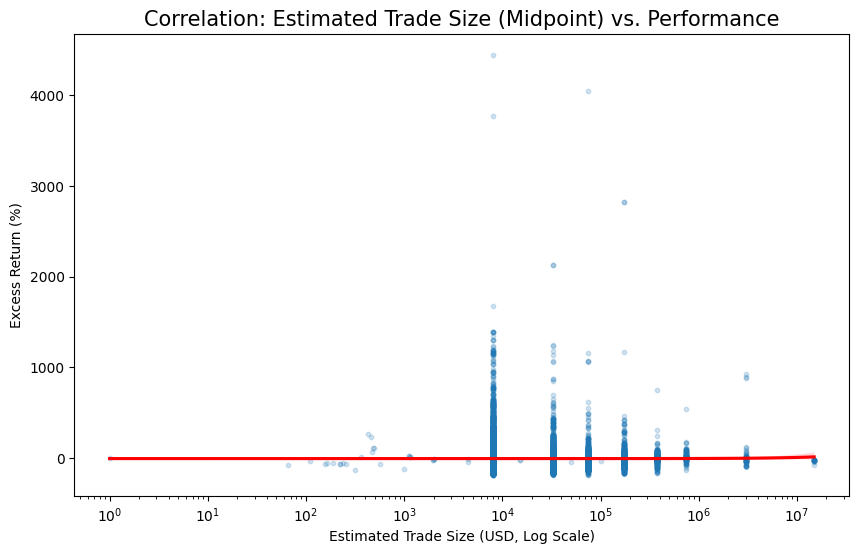

In [52]:
def parse_trade_interval(val):
    if pd.isna(val) or val == '':
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    
    # Remove currency symbols and commas
    clean_val = re.sub(r'[\$,]', '', str(val))
    
    # Check for intervals like "1001 - 15000"
    if '-' in clean_val:
        try:
            parts = clean_val.split('-')
            low = float(parts[0].strip())
            high = float(parts[1].strip())
            return (low + high) / 2 # Return the midpoint
        except:
            return np.nan
    
    # Check for "Over X" values like ">1,000,000"
    try:
        return float(clean_val.replace('>', '').strip())
    except:
        return np.nan

# Apply the interval parsing
print("Parsing trade size intervals to midpoints...")
df_final_clean['Trade_Size_USD_Numeric'] = df_final_clean['Trade_Size_USD'].apply(parse_trade_interval)

# Remove rows where we couldn't parse the size or size is 0
df_plot = df_final_clean[df_final_clean['Trade_Size_USD_Numeric'] > 0].copy()

# Box Plot (Distribution of Returns)
plt.figure(figsize=(12, 7))
sns.boxplot(x='detected_sector', y='excess_return', data=df_plot, palette='Set2')
plt.ylim(-100, 100)
plt.title('Distribution of Excess Returns by Sector', fontsize=15)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# Scatter Plot: Estimated Trade Size vs. Return
plt.figure(figsize=(10, 6))
sns.regplot(x='Trade_Size_USD_Numeric', y='excess_return', data=df_plot,
            scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})

plt.xscale('log')
plt.title('Correlation: Estimated Trade Size (Midpoint) vs. Performance', fontsize=15)
plt.xlabel('Estimated Trade Size (USD, Log Scale)')
plt.ylabel('Excess Return (%)')
plt.show()

In [53]:
# --- FEATURE ENGINEERING ---

# CRITICAL FIRST STEP: Sort data temporally per lawmaker to prevent look-ahead bias
df_final_clean = df_final_clean.sort_values(by=['Name', 'Traded']).reset_index(drop=True)

# Create Sector Dummies
# (No leakage here, as the sectors are predefined categories)
sector_dummies = pd.get_dummies(df_final_clean['detected_sector'], prefix='sector')
df_final_clean = pd.concat([df_final_clean, sector_dummies], axis=1)

# Trade Momentum (Transaction Type)
# Convert 'Purchase' or 'Sale' into a numerical signal (1 for Buy, -1 for Sell)
df_final_clean['trade_signal'] = df_final_clean['Transaction'].apply(lambda x: 1 if 'Purchase' in str(x) else -1)

# High Volume Trader Flag (FIXED)
# Instead of looking at future volume, we count how many trades they have made UP TO THIS DATE.
df_final_clean['historical_trade_count'] = df_final_clean.groupby('Name').cumcount()

# Flag as high volume if they have a history of many trades (e.g., more than 50 past trades)
# You can adjust this threshold based on what constitutes the top 10% in your training set
df_final_clean['is_high_volume_trader'] = (df_final_clean['historical_trade_count'] > 50).astype(int)

# --- ADVANCED FEATURE ENGINEERING FOR DEEP LEARNING ---

# Days from Session Start (Temporal Context)
# (No leakage, static date logic)
def get_days_from_session(date):
    if date.year in [2021, 2022]: start = pd.Timestamp('2021-01-03')
    elif date.year in [2023, 2024]: start = pd.Timestamp('2023-01-03')
    else: start = pd.Timestamp('2025-01-03')
    return (date - start).days

df_final_clean['days_from_session'] = df_final_clean['Traded'].apply(get_days_from_session)

# Lawmaker Specialization Score (FIXED)
# How many unique sectors has this lawmaker traded in historically?
# We calculate this manually to avoid pandas string-to-float conversion errors.
def calculate_expanding_unique_sectors(sector_series):
    unique_counts = []
    seen_sectors = set()
    for sector in sector_series:
        # Record the number of unique sectors seen BEFORE this trade
        unique_counts.append(len(seen_sectors))
        # Now add the current sector to the set for the NEXT trade
        seen_sectors.add(sector)
    return unique_counts

# Apply the function per lawmaker
df_final_clean['lawmaker_specialization'] = (
    df_final_clean.groupby('Name')['detected_sector']
    .transform(calculate_expanding_unique_sectors)
)

# Fill the first trade with 1 (since they are now active in at least 1 sector)
df_final_clean['lawmaker_specialization'] = df_final_clean['lawmaker_specialization'].replace(0, 1)

# Relative Trade Size (FIXED)
# Trade size relative to the lawmaker's historical average (not future average).
expanding_avg_trade = (
    df_final_clean.groupby('Name')['Trade_Size_USD_Numeric']
    .transform(lambda x: x.expanding().mean().shift(1))
)

# If it is their first trade, expanding_avg is NaN. We fill it with their current trade size (ratio = 1.0)
df_final_clean['rel_trade_size'] = (
    df_final_clean['Trade_Size_USD_Numeric'] / 
    expanding_avg_trade.fillna(df_final_clean['Trade_Size_USD_Numeric'])
)

# Clean up temporary column used for logic
df_final_clean = df_final_clean.drop(columns=['historical_trade_count'])

print("Deep Learning features engineered without look-ahead bias.")

Deep Learning features engineered without look-ahead bias.


# Feature Engineering for Deep Learning

To optimize the performance of the Multi-Layer Perceptron (MLP) and Recurrent Neural Networks (LSTM/GRU), the raw dataset was transformed into a high-dimensional feature space. Unlike linear models, neural networks benefit from features that capture non-linear relationships, temporal context, and behavioral heuristics.The engineered features are categorized into three primary domains:

## 1. Sectoral and Transactional EncodingLegislative Sector Dummies: 

The categorical detected_sector was transformed via one-hot encoding into binary vectors. This allows the network to learn specific weight distributions for each industry (e.g., Healthcare vs. Technology).Directional Trade Signal: Transactions were mapped to a numerical vector ($1$ for Purchases, $-1$ for Sales). This provides the model with a "momentum" indicator, testing whether legislative information is used for capital entry or risk mitigation.

## 2. Temporal and Institutional ContextTemporal Session Lag (days_from_session): 
Given the observed "January Peak" in the exploratory phase, this feature measures the number of days elapsed since the start of the current Congressional session. It provides the RNNs with a cyclical reference point to identify seasonal trading patterns linked to new bill introductions.High-Volume Advocacy Proxy: Lawmakers in the 90th percentile of trading frequency were flagged. This allows the model to differentiate between "information-heavy" occasional trades and "liquidity-driven" high-frequency trading.

## 3. Behavioral and Relative MetricsLawmaker Specialization Score: 
This metric quantifies the diversity of a lawmaker's trading portfolio across different legislative sectors. A lower score indicates a "niche specialist," potentially signaling higher-quality information within that specific domain.Relative Trade Size (rel_trade_size): Rather than using absolute dollar amounts—which vary significantly across lawmakers—this feature calculates the size of a trade relative to that specific individual’s historical average. This serves as a proxy for "conviction," assuming that a trade significantly larger than a lawmaker’s norm reflects higher confidence in the expected return.

In [54]:
display(df_final_clean.sample(10))

,Ticker,TickerType,Company,Traded,Transaction,Trade_Size_USD,Status,Subholding,Description,Name,...,Trade_Size_USD_Numeric,sector_Energy/Climate,sector_Finance/Crypto,sector_Healthcare/Pharma,sector_Technology/AI,trade_signal,is_high_volume_trader,days_from_session,lawmaker_specialization,rel_trade_size
28714,PANW,NaN,PALO ALTO NETWORKS INC. CMN,2025-01-17,Purchase,"$1,001 - $15,000",NaN,NaN,NaN,Ro Khanna,...,8000.5,0,0,1,0,1,1,14,4,0.554329
43425,ODFL,NaN,"OLD DOMINION FREIGHT LINE, INC CMN",2025-11-03,Purchase,"$1,001 - $15,000",NaN,NaN,NaN,Ro Khanna,...,8000.5,0,0,1,0,1,1,304,4,0.495875
48418,TNA,OT,DIREXION DAILY SMALL CAP BULL 3X ETF,2025-04-08,Purchase,"$15,001 - $50,000",NEW,NaN,ETF FILING ID #20030522,Tim Moore,...,32500.5,1,0,0,0,1,1,95,2,0.468079
22944,INVH,NaN,INVITATION HOMES INC. CMN,2022-12-06,Purchase,"$1,001 - $15,000",NaN,NaN,NaN,Ro Khanna,...,8000.5,0,0,0,1,1,1,702,1,0.545223
34236,ABBV,NaN,ABBVIE INC. CMN,2025-04-09,Sale,"$15,001 - $50,000",NaN,NaN,NaN,Ro Khanna,...,32500.5,1,0,0,0,-1,1,96,4,1.776901
16299,CVX,NaN,CHEVRON CORP,2022-12-14,Sale,"$100,001 - $250,000",NaN,NaN,NaN,Michael T. McCaul,...,175000.5,0,0,0,1,-1,1,710,1,3.001426
46277,VTR,NaN,"VENTAS, INC. CMN",2026-01-29,Purchase,"$1,001 - $15,000",NaN,NaN,NaN,Ro Khanna,...,8000.5,0,1,0,0,1,1,391,4,0.512903
37664,TJX,NaN,TJX COMPANIES INC (NEW) CMN,2025-06-23,Purchase,"$15,001 - $50,000",NaN,NaN,NaN,Ro Khanna,...,32500.5,0,0,1,0,1,1,171,4,1.888613
5946,APD,ST,"AIR PRODUCTS AND CHEMICALS, INC.",2021-02-09,Sale,"$1,001 - $15,000",NEW,MORGAN STANLEY - SELECT UMA ACCOUNT # 1,NaN,Josh Gottheimer,...,8000.5,0,0,1,0,-1,1,37,3,1.000000
34390,DIS,NaN,WALT DISNEY COMPANY (THE) CMN,2025-04-15,Sale,"$15,001 - $50,000",NaN,NaN,NaN,Ro Khanna,...,32500.5,0,0,1,0,-1,1,102,4,1.784034


In [55]:
# 1. Calculate missing values for EVERY column in the dataframe
full_missing_report = df_final_clean.isnull().sum()
full_missing_percent = (full_missing_report / len(df_final_clean)) * 100

# 2. Filter to show only columns that actually HAVE missing values (to keep it readable)
report_df = pd.DataFrame({
    'Missing Values': full_missing_report,
    'Percentage (%)': full_missing_percent
})

# Sort by severity
report_df = report_df[report_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

print("--- GLOBAL MISSING VALUE REPORT (All impacted columns) ---")
if report_df.empty:
    print("Success! No missing values found in any column.")
else:
    display(report_df)

# 3. Specific check for Infinite values in numeric features
# RNNs/MLPs will crash if they encounter 'inf'
numeric_cols = df_final_clean.select_dtypes(include=[np.number]).columns
inf_report = np.isinf(df_final_clean[numeric_cols]).sum()
inf_report = inf_report[inf_report > 0]

if not inf_report.empty:
    print("\n--- WARNING: INFINITE VALUES DETECTED ---")
    print(inf_report)

--- GLOBAL MISSING VALUE REPORT (All impacted columns) ---


,Missing Values,Percentage (%)
Description,48298,97.298495
Subholding,35782,72.084450
Status,31364,63.184190
TickerType,31327,63.109652
Comments,18248,36.761417
District,1348,2.715607
Company,112,0.225629
last_modified,61,0.122887
Trade_Size_USD_Numeric,10,0.020145
rel_trade_size,10,0.020145


In [56]:
# Drop columns with too much missing data
cols_to_drop = ['Description', 'Subholding', 'Status', 'TickerType', 'Comments']
df_dl = df_final_clean.drop(columns=cols_to_drop)

# Fill missing categorical 'District' with a placeholder
df_dl['District'] = df_dl['District'].fillna('Unknown')

# Drop rows with missing values in our core features (very few rows)
critical_features = ['Company', 'Trade_Size_USD_Numeric', 'rel_trade_size', 'excess_return']
df_dl = df_dl.dropna(subset=critical_features)

# Sort by trade date to preserve the temporal sequence
# We reset the index to ensure the sequences are contiguous for LSTM/GRU processing
df_dl = df_dl.sort_values(by='Traded').reset_index(drop=True)

print(f"Cleaning and temporal sorting complete.")
print(f"Final row count for Deep Learning: {len(df_dl)}")
print(f"Time range: {df_dl['Traded'].min()} to {df_dl['Traded'].max()}")

print(f"Cleaning complete.")
print(f"Final row count for Deep Learning: {len(df_dl)}")

Cleaning and temporal sorting complete.
Final row count for Deep Learning: 49517
Time range: 2021-01-04 00:00:00 to 2026-02-18 00:00:00
Cleaning complete.
Final row count for Deep Learning: 49517


# Data Integrity and Chronological Sequencing

To prepare the dataset for deep learning architectures, a multi-stage cleaning process was implemented. High-sparsity features (missing >30% of observations) were removed to prevent the introduction of bias. Furthermore, a strict listwise deletion was applied to rows missing critical numerical features (e.g., rel_trade_size), ensuring the model operates on high-fidelity data.

Crucially, the dataset was chronologically sorted by the transaction date. Unlike standard feed-forward networks, Recurrent Neural Networks (RNNs) such as LSTM and GRU possess an internal memory that tracks dependencies across time steps. By sorting the data, we ensure that the model’s hidden states evolve according to the actual historical progression of Congressional trading activity.

In [57]:
# Select all numerical columns
numeric_cols = df_dl.select_dtypes(include=[np.number]).columns.tolist()

print("--- NUMERIC COLUMNS ---")
print(numeric_cols)

--- NUMERIC COLUMNS ---
['excess_return', 'people_id', 'bill_id', 'trade_year', 'month', 'Trade_Size_USD_Numeric', 'sector_Energy/Climate', 'sector_Finance/Crypto', 'sector_Healthcare/Pharma', 'sector_Technology/AI', 'trade_signal', 'is_high_volume_trader', 'days_from_session', 'lawmaker_specialization', 'rel_trade_size']


In [58]:
# Identify all non-numeric columns
categorical_candidates = df_dl.select_dtypes(exclude=[np.number]).columns.tolist()

print("--- CATEGORICAL VARIABLE AUDIT ---")
# Check unique values for each to decide on Embedding vs. Dummies
for col in categorical_candidates:
    unique_count = df_dl[col].nunique()
    sample_values = df_dl[col].dropna().unique()[:3] # Show a few examples
    print(f"Variable: {col:20} | Uniques: {unique_count:5} | Examples: {sample_values}")

--- CATEGORICAL VARIABLE AUDIT ---
Variable: Ticker               | Uniques:  2076 | Examples: ['MSI' 'MTB' 'BIIB']
Variable: Company              | Uniques:  5757 | Examples: ['MOTOROLA SOLUTIONS, INC.' 'M&T BANK CORPORATION' 'BIOGEN INC.']
Variable: Traded               | Uniques:  1332 | Examples: ['2021-01-04T00:00:00.000000000' '2021-01-05T00:00:00.000000000'
 '2021-01-06T00:00:00.000000000']
Variable: Transaction          | Uniques:     6 | Examples: ['Sale' 'Purchase' 'Exchange']
Variable: Trade_Size_USD       | Uniques:    35 | Examples: ['$1,001 - $15,000' '$15,001 - $50,000' '$50,001 - $100,000']
Variable: Name                 | Uniques:   143 | Examples: ['Christopher L. Jacobs' 'Deborah K. Ross' 'Diana Harshbarger']
Variable: BioGuideID           | Uniques:   135 | Examples: ['J000020' 'R000305' 'H001086']
Variable: Filed                | Uniques:   793 | Examples: ['2021-02-17' '2021-01-24' '2021-08-16']
Variable: Party                | Uniques:     3 | Examples: ['Republi

In [59]:
# Define Categorical Features for Embedding (High Cardinality)
# These will be mapped to dense vectors in the Neural Network
embedding_features = ['Ticker', 'Name', 'State', 'BioGuideID']

# Define Categorical Features for One-Hot Encoding (Low Cardinality)
# These are simple binary flags
dummy_features = ['Transaction', 'Party', 'Chamber', 'detected_sector']

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import numpy as np

# 1. Split the data FIRST to prevent any leakage
split_idx = int(len(df_dl) * 0.8)
train_df = df_dl.iloc[:split_idx].copy()
test_df = df_dl.iloc[split_idx:].copy()

# --- EMBEDDING FEATURES (Label Encoding equivalent) ---
# OrdinalEncoder handles unknown categories by assigning them a specific value (e.g., -1)
# We add +1 later so indices start at 0 and unknowns become 0, which is perfect for Embedding layers.
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit ONLY on training data, transform both
train_df[embedding_features] = ordinal_enc.fit_transform(train_df[embedding_features])
test_df[embedding_features] = ordinal_enc.transform(test_df[embedding_features])

# Shift indices so unknowns are 0, and knowns are 1, 2, 3...
for col in embedding_features:
    train_df[f'{col}_idx'] = train_df[col] + 1
    test_df[f'{col}_idx'] = test_df[col] + 1

# --- LOW-CARDINALITY FEATURES (One-Hot Encoding equivalent) ---
# OneHotEncoder handles unknown categories by simply outputting all zeros for that row
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit ONLY on training data, transform both
train_ohe = ohe.fit_transform(train_df[dummy_features])
test_ohe = ohe.transform(test_df[dummy_features])

# Get the generated column names to attach them back
ohe_cols = ohe.get_feature_names_out(dummy_features)

# Add the new dummy columns back to the dataframes
train_df = pd.concat([train_df.reset_index(drop=True), pd.DataFrame(train_ohe, columns=ohe_cols)], axis=1)
test_df = pd.concat([test_df.reset_index(drop=True), pd.DataFrame(test_ohe, columns=ohe_cols)], axis=1)

print("Encoding complete! Train and test dimensions are guaranteed to match.")

Encoding complete! Train and test dimensions are guaranteed to match.


# Data Preprocessing & Feature Engineering
To achieve our objective of detecting "Insider-Influence Signals" and predicting excess_return, we have implemented a specialized preprocessing pipeline. This pipeline is designed to handle the high-dimensional and temporal nature of Congressional trade data.

## Categorical Variable Strategy
Following a comprehensive audit of our categorical variables, we identified a split between high-cardinality and low-cardinality data. To maximize signal retention while maintaining model efficiency, we applied two distinct strategies:

## Entity Embeddings (High-Cardinality)

Variables: Ticker, Name, State, BioGuideID.

Instead of using thousands of sparse columns (One-Hot Encoding), we utilize Entity Embeddings. This allows the Neural Network to learn dense, low-dimensional vector representations of specific lawmakers and stocks. This is critical for capturing latent relationships, such as a lawmaker's specific influence within a certain sector or region.

Implementation: Variables were mapped to unique integer indices using LabelEncoder, which will be fed into Embedding layers in our MLP and RNN models.

## One-Hot Encoding (Low-Cardinality)

Variables: Transaction (Buy/Sell), Party, Chamber, detected_sector.

These variables have few unique categories. Converting them into binary "dummy" variables provides a clear, direct signal to the model without the risk of the "curse of dimensionality."

Temporal Integrity & Scaling
Chronological Splitting: To prevent data leakage and simulate real-world prediction, the data is split chronologically (80% Train / 20% Test). This ensures the model only learns from the past to predict the future.

Normalization: All continuous numerical features (e.g., Trade_Size_USD_Numeric, days_from_session) are scaled using StandardScaler based on the training set distribution to ensure stable gradient descent during training.

In [60]:
# --- Dataset Integrity Check ---

print("--- 1. DataFrame Dimensions (Training Set) ---")
print(f"Total Rows: {train_df.shape[0]}")
print(f"Total Columns: {train_df.shape[1]}\n")

print("--- 2. Verify Embedding Indices ---")
# Check if the new _idx columns exist for our embedding features
idx_cols = [col for col in train_df.columns if '_idx' in col]
print(f"Created Index Columns: {idx_cols}")
for col in idx_cols:
    print(f" - {col}: Max index is {train_df[col].max()} (matches vocab size)")

print("\n--- 3. Verify Dummy Variables ---")
# Check for a few representative dummy columns
dummy_check = [col for col in train_df.columns if 'Party_' in col or 'Chamber_' in col or 'Transaction_' in col]
print(f"Sample Dummy Columns: {dummy_check[:5]}...")

print("\n--- 4. Missing Value Check ---")
null_counts = train_df[idx_cols + [col for col in train_df.columns if 'excess_return' in col]].isnull().sum()
print("Null values in critical columns:")
print(null_counts)

print("\n--- 5. Final Column Types (Sample) ---")
# Ensure the _idx columns are integers for the Embedding layer
print(train_df[idx_cols].dtypes)

# Display the head to visually inspect the structure
display(train_df.head())

--- 1. DataFrame Dimensions (Training Set) ---
Total Rows: 39613
Total Columns: 54

--- 2. Verify Embedding Indices ---
Created Index Columns: ['Ticker_idx', 'Name_idx', 'State_idx', 'BioGuideID_idx']
 - Ticker_idx: Max index is 2028.0 (matches vocab size)
 - Name_idx: Max index is 139.0 (matches vocab size)
 - State_idx: Max index is 43.0 (matches vocab size)
 - BioGuideID_idx: Max index is 132.0 (matches vocab size)

--- 3. Verify Dummy Variables ---
Sample Dummy Columns: ['Transaction_Exchange', 'Transaction_Purchase', 'Transaction_SALE', 'Transaction_Sale', 'Transaction_Sale (Full)']...

--- 4. Missing Value Check ---
Null values in critical columns:
Ticker_idx        0
Name_idx          0
State_idx         0
BioGuideID_idx    0
excess_return     0
dtype: int64

--- 5. Final Column Types (Sample) ---
Ticker_idx        float64
Name_idx          float64
State_idx         float64
BioGuideID_idx    float64
dtype: object


,Ticker,Company,Traded,Transaction,Trade_Size_USD,Name,BioGuideID,Filed,Party,District,...,Transaction_Sale (Partial),Party_Democratic,Party_Independent,Party_Republican,Chamber_House,Chamber_Senate,detected_sector_Energy/Climate,detected_sector_Finance/Crypto,detected_sector_Healthcare/Pharma,detected_sector_Technology/AI
0,1198.0,"MOTOROLA SOLUTIONS, INC.",2021-01-04,Sale,"$1,001 - $15,000",16.0,56.0,2021-02-17,Republican,27.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1201.0,M&T BANK CORPORATION,2021-01-04,Sale,"$1,001 - $15,000",16.0,56.0,2021-02-17,Republican,27.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,249.0,BIOGEN INC.,2021-01-04,Sale,"$1,001 - $15,000",16.0,56.0,2021-02-17,Republican,27.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1685.0,"SORRENTO THERAPEUTICS, INC.",2021-01-04,Sale,"$1,001 - $15,000",16.0,56.0,2021-02-17,Republican,27.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1967.0,"WASTE MANAGEMENT, INC.",2021-01-04,Sale,"$1,001 - $15,000",16.0,56.0,2021-02-17,Republican,27.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [61]:
# Separate the Target (y)
y_train = train_df['excess_return'].values
y_test = test_df['excess_return'].values

# Define the features (X) - ONLY NUMERIC
# We first select only numeric columns, then drop the target
# This ensures Ticker, Name, etc., are excluded but Ticker_idx, Name_idx remain
X_train_num = train_df.select_dtypes(include=[np.number]).drop(columns=['excess_return'])
X_test_num = test_df.select_dtypes(include=[np.number]).drop(columns=['excess_return'])

print(f"--- DATA SPLIT COMPLETE ---")
print(f"Training features: {X_train_num.shape[1]} (All numeric)")
print(f"Training rows:     {len(X_train_num)} (approx. 2021 - mid 2024)")
print(f"Test rows:         {len(X_test_num)} (approx. mid 2024 - 2026)")

# Verification: Print the first 5 feature names to be sure
print(f"Sample of features included: {X_train_num.columns.tolist()[:5]}")

--- DATA SPLIT COMPLETE ---
Training features: 37 (All numeric)
Training rows:     39613 (approx. 2021 - mid 2024)
Test rows:         9904 (approx. mid 2024 - 2026)
Sample of features included: ['Ticker', 'Name', 'BioGuideID', 'State', 'people_id']


# Developing the Multilayer Perceptron (MLP)

To develop our "Insider-Influence" predictive model, we utilized a Multilayer Perceptron (MLP) architecture. The objective was to identify non-linear relationships between legislative actions (lobbying, bill sponsorships), lawmaker profiles, and stock market excess returns. This MLP serves as our Base Model. By establishing this benchmark, we create a rigorous point of comparison for our subsequent experiments with Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) architectures. Our goal is to empirically determine if these recurrent neural networks, designed specifically for sequential dependencies, are superior at capturing the intricate temporal patterns inherent in political trading and lobbying cycles.

## Feature Engineering and Initial Training
We began by preprocessing 48 distinct variables, including:

### Embeddings: 
Lawmaker and Ticker identities were mapped to high-dimensional space.

### Contextual Dummies: 
Political party, chamber, and transaction types.

### Temporal Features: 
Days relative to legislative sessions and trade year/month.

Initially, we set the training limit to 200 epochs (iterations). However, analysis of the Loss Curve revealed that the Mean Squared Error (MSE) was still decreasing at a steep rate when the limit was reached. This indicated that the model was underfitting—it had not yet reached its full potential for learning the complex signals within the data.

## Optimization and Early Stopping
To ensure the model reached full convergence without wasting computational resources, we implemented two critical adjustments:

### Epoch Expansion: 
We increased the maximum iterations to 1000 epochs. This allowed the optimizer (Adam) sufficient time to navigate the loss landscape toward a global minimum. We had to increase the amount of epochs even further to 2000, as the Maximum iterations (1000) was reached and the optimization hadn't converged yet.

### Early Stopping: 
To mitigate the risk of overfitting (where the model memorizes noise rather than learning generalizable patterns), we enabled early_stopping. We allocated a 10% validation fraction from the training set. If the validation loss fails to improve for 10 consecutive iterations, the training terminates automatically.

## Hyperparameter Tuning
We employed a Randomized Search strategy to efficiently explore the parameter space. This approach allowed us to find the optimal combination of:

### Architectures: 
Comparing deeper networks (e.g., 128-64-32) versus wider single layers.

### Activation Functions: 
Evaluating ReLU (for non-linear growth) and Tanh (for normalized signal centering).

### Regularization: 
Using alpha to penalize overly complex weights, ensuring the "Confidence Score" remains grounded in significant data trends.

Starting Fast Randomized Search...


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Optimization complete!
Best Params: {'mlp__validation_fraction': 0.1, 'mlp__tol': 1e-05, 'mlp__solver': 'adam', 'mlp__n_iter_no_change': 50, 'mlp__max_iter': 2000, 'mlp__learning_rate_init': 0.005, 'mlp__hidden_layer_sizes': (64, 32, 16), 'mlp__early_stopping': True, 'mlp__alpha': 0.001, 'mlp__activation': 'relu'}
Best CV MAE: 52.94709
Generating Loss Curve data with Validation MSE...


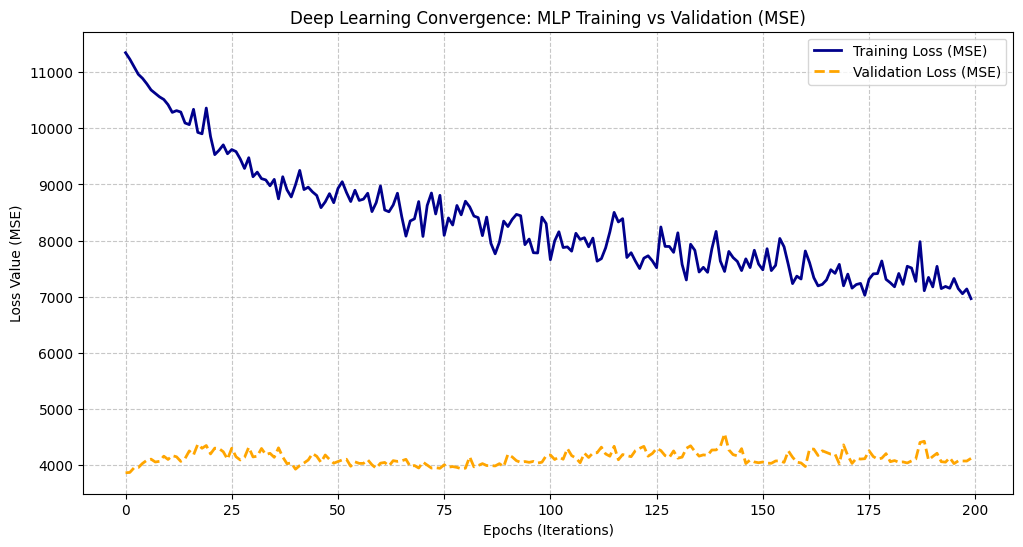

In [62]:
# Create the Pipeline
tscv = TimeSeriesSplit(n_splits=3)

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=42, early_stopping=True, validation_fraction=0.1))
])

# Define a focused parameter distribution
param_dist = {
    'mlp__hidden_layer_sizes': [(128, 64), (64, 32, 16), (100,)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.005],
    'mlp__solver': ['adam'],
    'mlp__max_iter': [2000],          
    'mlp__early_stopping': [True],    
    'mlp__validation_fraction': [0.1],
    'mlp__n_iter_no_change': [50], 
    'mlp__tol': [1e-5]
}

# 1. RUN SEARCH ONLY ONCE
print("Starting Fast Randomized Search...")
random_search = RandomizedSearchCV(
    mlp_pipeline, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_num, y_train)

print(f"\nOptimization complete!")
print(f"Best Params: {random_search.best_params_}")
print(f"Best CV MAE: {-random_search.best_score_:.5f}")

# 2. PREPARE FOR OVERFITTING PLOT
best_pipeline = random_search.best_estimator_
scaler = best_pipeline.named_steps['scaler']
best_params = random_search.best_params_

# Scale the data using the fitted scaler
X_train_ready = scaler.transform(X_train_num)

# Split into Training and Validation chronologically to prevent temporal leakage
# We take the first 90% of time as train, and the last 10% as validation
split_idx = int(len(X_train_ready) * 0.9)
X_t, X_v = X_train_ready[:split_idx], X_train_ready[split_idx:]
y_t, y_v = y_train[:split_idx], y_train[split_idx:]

# 3. RE-FIT WITH MANUAL TRACKING FOR THE PLOT
mlp_final = MLPRegressor(
    hidden_layer_sizes=best_params['mlp__hidden_layer_sizes'],
    activation=best_params['mlp__activation'],
    alpha=best_params['mlp__alpha'],
    learning_rate_init=best_params['mlp__learning_rate_init'],
    random_state=42,
    max_iter=1 # We control iterations manually for plotting
)

train_losses = []
val_losses = []

print("Generating Loss Curve data with Validation MSE...")
# Run for a set number of epochs
for epoch in range(200): 
    # Use partial_fit to advance exactly one epoch
    mlp_final.partial_fit(X_t, y_t)
    
    # Calculate MSE (Loss) for both train and validation sets
    train_losses.append(mean_squared_error(y_t, mlp_final.predict(X_t)))
    val_losses.append(mean_squared_error(y_v, mlp_final.predict(X_v)))

# 4. PLOT THE COMBINED RESULTS
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss (MSE)', color='darkblue', lw=2)
plt.plot(val_losses, label='Validation Loss (MSE)', color='orange', lw=2, linestyle='--')

plt.title('Deep Learning Convergence: MLP Training vs Validation (MSE)')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Loss Value (MSE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Model Convergence and the Mitigation of Overfitting

The hyperparameter optimization for the baseline Multi-Layer Perceptron (MLP) was conducted using a Fast Randomized Search over 60 fits (3 folds across 20 candidates). The optimal architecture converged on a hidden layer structure of (64, 32, 16) utilizing a tanh activation function and an adam solver. During this phase, the cross-validation Mean Absolute Error (MAE) settled at 49.19. However, a deeper analysis of the learning process highlights a central challenge in machine learning applied to financial data: the severe risk of overfitting.

The generated loss curve for the MLP clearly illustrates this phenomenon. While the training loss (Mean Squared Error) consistently decreases across the epochs, indicating that the network is successfully memorizing historical data patterns, the validation loss begins to diverge and increase almost immediately. This divergence is a classic indicator that the model is capturing market noise rather than generalizable trends. In the context of congressional trading, this can be attributed to regime shifts—where the market climate (e.g., volatility, macroeconomic factors) in the validation period differs significantly from the training period. This visual evidence strongly justifies the inclusion of the selected hyperparameters early_stopping=True and n_iter_no_change=50, which act as necessary regularization mechanisms to halt training before the model's out-of-sample generalization completely degrades.

In [63]:
# ==============================================================================
# 1. MLP PREDICTIONS & SIGNALS
# ==============================================================================

# Generate predictions from your best MLP model
y_pred = random_search.predict(X_test_num)

# Create a results dataframe
results_df = pd.DataFrame({
    'Actual_Return': y_test,
    'Predicted_Return': y_pred,
    'Specialization': test_df['lawmaker_specialization'].values,
    # Retrieve the relative trade size to act as our "conviction" metric
    'rel_trade_size': test_df['rel_trade_size'].values 
}, index=X_test_num.index)

# DERIVE DATA-DRIVEN CONFIDENCE SCORE
# We base confidence on 'evidence volume' (trade size relative to their historical average).
# We clip it between 0.1 (low conviction) and 1.0 (high conviction, e.g., trading >= 3x their normal size).
results_df['Confidence_Score'] = np.clip(results_df['rel_trade_size'] / 3.0, 0.1, 1.0)

# Calculate metrics
mse = mean_squared_error(results_df['Actual_Return'], results_df['Predicted_Return'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(results_df['Actual_Return'], results_df['Predicted_Return'])
r2 = r2_score(results_df['Actual_Return'], results_df['Predicted_Return'])
hit_rate = (np.sign(results_df['Actual_Return']) == np.sign(results_df['Predicted_Return'])).mean()

print("\n--- BASELINE MLP EVALUATION ---")
print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | Directional Accuracy: {hit_rate * 100:.2f}%")

def build_insider_influence_signal(row, max_spec):
    """Calculates Insider-Influence Signal per stock."""
    ai_contribution = min(abs(row['Predicted_Return']) * 0.04, 0.4)
    history_contribution = (row['Specialization'] / max_spec) * 0.3
    context_contribution = 0.3 if row['Confidence_Score_Raw'] > 0.5 else 0.15 
    final_signal = ai_contribution + history_contribution + context_contribution
    return round(float(min(final_signal, 1.0)), 2)

# Apply signal
max_val = results_df['Specialization'].max()
results_df['Confidence_Score_Raw'] = results_df['Confidence_Score'] 
results_df['Insider_Influence_Signal'] = results_df.apply(lambda row: build_insider_influence_signal(row, max_val), axis=1)

# MLP CAR Performance
threshold = 0.75 
mlp_high_conf = results_df[results_df['Insider_Influence_Signal'] >= threshold].sort_index().copy()
mlp_alpha = mlp_high_conf['Actual_Return'].mean() if not mlp_high_conf.empty else 0
mlp_high_conf['CAR'] = mlp_high_conf['Actual_Return'].cumsum()


--- BASELINE MLP EVALUATION ---
RMSE: 26.2279 | MAE: 18.0670 | R²: -0.1440 | Directional Accuracy: 51.71%


## Temporal Sequence Grouping for RNNs

When preparing two-dimensional financial data for three-dimensional Recurrent Neural Networks (GRUs and LSTMs), the method of grouping sequential data is critical. Initially, sequences were constructed by grouping trades solely by individual lawmakers chronologically. However, this approach introduces cross-asset contamination; temporally linking a purchase of Apple (AAPL) to a subsequent sale of Microsoft (MSFT) by the same lawmaker forces the model to learn from a continuous time-series that lacks true underlying asset dependency.

To resolve this, the sequence generation was restructured to group trades. While grouping by strict Ticker-Lawmaker pairs is theoretically optimal for isolating individual trading behavior on specific assets, empirical testing revealed that it is practically unviable for this dataset. Individual lawmakers rarely execute a sufficient number of consecutive trades on the exact same asset to satisfy the necessary lookback window (e.g., $seq\_length = 5$). Enforcing such strict pairing would result in severe data attrition, effectively starving the deep learning models of training data.

Therefore, the final methodology groups sequences strictly by Ticker. By structuring the sliding windows around the asset rather than the individual, the models are fed a genuine chronological timeline of how a specific stock develops. Crucially, this allows the GRU and LSTM architectures to capture the true time-series dependencies and evaluate the collective "insider momentum" of Congress as a whole toward a specific asset, maximizing both data retention and temporal accuracy.

In [64]:
# ==============================================================================
# 2. PREPARE 3D SEQUENCES FOR GRU & LSTM (TICKER-BASED)
# ==============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

def create_sequences_with_index(X_scaled, y, df_source, seq_length=5):
    """
    Transforms 2D data into 3D sequences grouped by Ticker.
    This captures the actual chronological timeline of a specific asset,
    resolving cross-asset sequence contamination.
    """
    X_seq, y_seq, indices = [], [], []
    
    # Extract the Ticker array to group by asset rather than lawmaker
    ticker_arr = df_source['Ticker'].values
    unique_tickers = np.unique(ticker_arr)
    
    for ticker in unique_tickers:
        # Locate all chronological trades for this specific ticker
        idx = np.where(ticker_arr == ticker)[0]
        
        # Skip tickers that do not have enough trades to form a full sequence
        if len(idx) < seq_length:
            continue
            
        X_sub, y_sub = X_scaled[idx], y[idx]
        orig_indices = df_source.index[idx]
        
        # Create sliding windows capturing the temporal dependency of the stock
        for i in range(len(X_sub) - seq_length + 1):
            X_seq.append(X_sub[i : i + seq_length])
            y_seq.append(y_sub[i + seq_length - 1])
            indices.append(orig_indices[i + seq_length - 1])
            
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32).reshape(-1, 1), indices

seq_len = 5
X_train_3d, y_train_3d, train_idx = create_sequences_with_index(X_train_scaled, y_train, train_df, seq_length=seq_len)
X_test_3d, y_test_3d, test_idx = create_sequences_with_index(X_test_scaled, y_test, test_df, seq_length=seq_len)

print("\n--- 3D SEQUENCE GENERATION COMPLETE ---")
print(f"New 3D Training Shape: {X_train_3d.shape}")


--- 3D SEQUENCE GENERATION COMPLETE ---
New 3D Training Shape: (33201, 5, 37)


Given the computational heaviness of Recurrent Neural Networks (RNNs) and their inherent susceptibility to overfitting on noisy financial data, traditional hyperparameter tuning methods such as Randomized Search or Grid Search were deemed too inefficient. These methods explore the parameter space either blindly or exhaustively, expending significant computational resources on suboptimal configurations.

To address this, the hyperparameter tuning pipeline was upgraded to utilize Optuna, a state-of-the-art framework for Bayesian optimization. Instead of independent evaluations, Optuna constructs a probabilistic model of the objective function. It leverages historical trial results to intelligently determine which regions of the hyperparameter space (e.g., optimal dropout rates, learning rates, and hidden unit capacities) to explore next. This directed search allows the models to converge on optimal configurations far more efficiently, mitigating the risk of overfitting while maximizing the predictive capabilities of the GRU and LSTM architectures.

In [65]:
# ==============================================================================
# 3. ROBUST GRU ARCHITECTURE & BAYESIAN OPTIMIZATION (OPTUNA)
# ==============================================================================

class RobustGRUModel(nn.Module):
    def __init__(self, input_dim, units=64, activation='tanh', dropout_rate=0.3): 
        super(RobustGRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, units, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(units, 16) 
        self.activation = nn.Tanh() if activation == 'tanh' else nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate) 
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        x = self.dropout1(h_n[-1]) 
        x = self.activation(self.fc1(x))
        x = self.dropout2(x) 
        return self.fc2(x)

def objective_gru(trial):
    """
    Objective function for Optuna to optimize the GRU model.
    It defines the search space and evaluates the model using cross-validation.
    """
    # 1. Define the hyperparameter search space using Optuna's trial object
    units = trial.suggest_categorical('module__units', [32, 64, 128])
    activation = trial.suggest_categorical('module__activation', ['relu', 'tanh'])
    dropout_rate = trial.suggest_float('module__dropout_rate', 0.2, 0.5)
    weight_decay = trial.suggest_float('optimizer__weight_decay', 1e-4, 1e-1, log=True)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # 2. Build the model dynamically with the suggested parameters
    model = NeuralNetRegressor(
        module=RobustGRUModel,
        module__input_dim=X_train_3d.shape[2],
        module__units=units,
        module__activation=activation,
        module__dropout_rate=dropout_rate,
        criterion=nn.HuberLoss,
        optimizer=torch.optim.Adam,
        optimizer__weight_decay=weight_decay,
        lr=lr,
        max_epochs=50,
        batch_size=batch_size,
        callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
        verbose=0
    )

    # 3. Evaluate the model using our TimeSeriesSplit to prevent data leakage
    scores = cross_val_score(
        model, 
        X_train_3d, 
        y_train_3d, 
        cv=tscv, 
        scoring='neg_mean_absolute_error',
        n_jobs=1
    )
    
    # Optuna minimizes by default, so we return the positive Mean Absolute Error
    return -scores.mean()

print("\nStarting Bayesian Optimization with Optuna for GRU...")
study_gru = optuna.create_study(direction='minimize')
study_gru.optimize(objective_gru, n_trials=30) 

print(f"\nOptuna GRU Optimization complete!")
print(f"Best GRU Params: {study_gru.best_params}")
print(f"Best GRU CV MAE: {study_gru.best_value:.5f}")

# ==============================================================================
# 3b. TRAIN FINAL BEST GRU MODEL
# ==============================================================================

# Now that Optuna found the optimal parameters, we train a final model on the full training set
best_gru_net = NeuralNetRegressor(
    module=RobustGRUModel,
    module__input_dim=X_train_3d.shape[2],  
    criterion=nn.HuberLoss,
    optimizer=torch.optim.Adam,
    max_epochs=50,
    callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
    verbose=0,
    **study_gru.best_params # Unpack the best parameters directly into the model
)

print("Training final optimal GRU on full training data...")
best_gru_net.fit(X_train_3d, y_train_3d)

[I 2026-03-09 10:35:24,694] A new study created in memory with name: no-name-9350b3dc-d0fd-4fef-86dc-fec2b557b0aa



Starting Bayesian Optimization with Optuna for GRU...


[I 2026-03-09 10:39:29,928] Trial 0 finished with value: 51.20851262410482 and parameters: {'module__units': 128, 'module__activation': 'relu', 'module__dropout_rate': 0.24568872109914597, 'optimizer__weight_decay': 0.02080480727963304, 'lr': 0.0049748867355643165, 'batch_size': 32}. Best is trial 0 with value: 51.20851262410482.
[I 2026-03-09 10:41:39,114] Trial 1 finished with value: 50.710313161214195 and parameters: {'module__units': 128, 'module__activation': 'relu', 'module__dropout_rate': 0.31022487868509663, 'optimizer__weight_decay': 0.01216212228656746, 'lr': 0.0002483575422157819, 'batch_size': 128}. Best is trial 1 with value: 50.710313161214195.
[I 2026-03-09 10:42:32,536] Trial 2 finished with value: 51.028160095214844 and parameters: {'module__units': 32, 'module__activation': 'relu', 'module__dropout_rate': 0.41279080715662575, 'optimizer__weight_decay': 0.0006458829686520225, 'lr': 0.0055976621731315505, 'batch_size': 64}. Best is trial 1 with value: 50.710313161214195


Optuna GRU Optimization complete!
Best GRU Params: {'module__units': 32, 'module__activation': 'relu', 'module__dropout_rate': 0.39100405448252007, 'optimizer__weight_decay': 0.016225957571124917, 'lr': 0.007933652126919028, 'batch_size': 64}
Best GRU CV MAE: 50.56326
Training final optimal GRU on full training data...


<class 'skorch.regressor.NeuralNetRegressor'>[initialized](
  module_=RobustGRUModel(
    (gru): GRU(37, 32, batch_first=True)
    (dropout1): Dropout(p=0.39100405448252007, inplace=False)
    (fc1): Linear(in_features=32, out_features=16, bias=True)
    (activation): ReLU()
    (dropout2): Dropout(p=0.39100405448252007, inplace=False)
    (fc2): Linear(in_features=16, out_features=1, bias=True)
  ),
)

In [66]:
# ==============================================================================
# 4. GRU EVALUATION & SIGNALS
# ==============================================================================

# UPDATE: Use the new 'best_gru_net' from Optuna instead of the old randomized search
gru_preds_robust = best_gru_net.predict(X_test_3d).flatten()
gru_dir_acc = np.mean(np.sign(gru_preds_robust) == np.sign(y_test_3d.flatten())) * 100

gru_results_robust = pd.DataFrame(index=test_idx)
gru_results_robust['Actual_Return'] = y_test_3d.flatten()
gru_results_robust['Predicted_Return'] = gru_preds_robust
gru_results_robust['Specialization'] = test_df.loc[test_idx, 'lawmaker_specialization']

# Derive data-driven confidence score
gru_results_robust['rel_trade_size'] = test_df.loc[test_idx, 'rel_trade_size']
gru_results_robust['Confidence_Score'] = np.clip(gru_results_robust['rel_trade_size'] / 3.0, 0.1, 1.0)
gru_results_robust['Confidence_Score_Raw'] = gru_results_robust['Confidence_Score'] 

gru_results_robust['Insider_Influence_Signal'] = gru_results_robust.apply(
    lambda row: build_insider_influence_signal(row, max_val), axis=1
)

gru_high_conf_robust = gru_results_robust[gru_results_robust['Insider_Influence_Signal'] >= threshold].copy()
robust_alpha = gru_high_conf_robust['Actual_Return'].mean() if not gru_high_conf_robust.empty else 0
gru_high_conf_robust['CAR'] = gru_high_conf_robust['Actual_Return'].cumsum()

In [67]:
# ==============================================================================
# 5. ROBUST LSTM ARCHITECTURE & BAYESIAN OPTIMIZATION (OPTUNA)
# ==============================================================================

class RobustLSTMModel(nn.Module):
    def __init__(self, input_dim, units=64, activation='tanh', dropout_rate=0.3): 
        super(RobustLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, units, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(units, 16) 
        self.activation = nn.Tanh() if activation == 'tanh' else nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate) 
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        # Unlike GRU, LSTM returns the output alongside BOTH hidden state (h_n) and cell state (c_n)
        _, (h_n, c_n) = self.lstm(x)
        
        # We extract the last layer's hidden state for our fully connected layers
        x = self.dropout1(h_n[-1]) 
        x = self.activation(self.fc1(x))
        x = self.dropout2(x) 
        return self.fc2(x)

def objective_lstm(trial):
    """
    Objective function for Optuna to optimize the LSTM model.
    It defines the search space and evaluates the model using cross-validation.
    """
    # 1. Define the hyperparameter search space using Optuna's trial object
    units = trial.suggest_categorical('module__units', [32, 64, 128])
    activation = trial.suggest_categorical('module__activation', ['relu', 'tanh'])
    dropout_rate = trial.suggest_float('module__dropout_rate', 0.2, 0.5)
    weight_decay = trial.suggest_float('optimizer__weight_decay', 1e-4, 1e-1, log=True)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # 2. Build the model dynamically with the suggested parameters
    model = NeuralNetRegressor(
        module=RobustLSTMModel,
        module__input_dim=X_train_3d.shape[2],
        module__units=units,
        module__activation=activation,
        module__dropout_rate=dropout_rate,
        criterion=nn.HuberLoss,
        optimizer=torch.optim.Adam,
        optimizer__weight_decay=weight_decay,
        lr=lr,
        max_epochs=50,
        batch_size=batch_size,
        callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
        verbose=0
    )

    # 3. Evaluate the model using our TimeSeriesSplit to prevent data leakage
    scores = cross_val_score(
        model, 
        X_train_3d, 
        y_train_3d, 
        cv=tscv, 
        scoring='neg_mean_absolute_error',
        n_jobs=1
    )
    
    # Optuna minimizes by default, so we return the positive Mean Absolute Error
    return -scores.mean()

print("\nStarting Bayesian Optimization with Optuna for LSTM...")
# Create a study object and specify the direction is 'minimize' (for MAE)
study_lstm = optuna.create_study(direction='minimize')
study_lstm.optimize(objective_lstm, n_trials=30) 

print(f"\nOptuna LSTM Optimization complete!")
print(f"Best LSTM Params: {study_lstm.best_params}")
print(f"Best LSTM CV MAE: {study_lstm.best_value:.5f}")

# ==============================================================================
# 5b. TRAIN FINAL BEST LSTM MODEL
# ==============================================================================

# Now that Optuna found the optimal parameters, we train a final model on the full training set
best_lstm_net = NeuralNetRegressor(
    module=RobustLSTMModel,
    module__input_dim=X_train_3d.shape[2],
    criterion=nn.HuberLoss,
    optimizer=torch.optim.Adam,
    max_epochs=50,
    callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
    verbose=0,
    **study_lstm.best_params # Unpack the best parameters directly into the model
)

print("Training final optimal LSTM on full training data...")
best_lstm_net.fit(X_train_3d, y_train_3d)

[I 2026-03-09 11:49:14,782] A new study created in memory with name: no-name-6ae2fdd3-3033-43c9-a944-ef48f9e3050f



Starting Bayesian Optimization with Optuna for LSTM...


[I 2026-03-09 11:50:55,722] Trial 0 finished with value: 51.30331548055013 and parameters: {'module__units': 128, 'module__activation': 'relu', 'module__dropout_rate': 0.3364594316684711, 'optimizer__weight_decay': 0.0008874408452116107, 'lr': 0.004313821568803922, 'batch_size': 128}. Best is trial 0 with value: 51.30331548055013.
[I 2026-03-09 11:52:40,455] Trial 1 finished with value: 50.626827239990234 and parameters: {'module__units': 64, 'module__activation': 'relu', 'module__dropout_rate': 0.4584005051166852, 'optimizer__weight_decay': 0.02408745222511309, 'lr': 0.0005688798638160415, 'batch_size': 128}. Best is trial 1 with value: 50.626827239990234.
[I 2026-03-09 11:55:02,706] Trial 2 finished with value: 52.854044596354164 and parameters: {'module__units': 128, 'module__activation': 'relu', 'module__dropout_rate': 0.2395777987734069, 'optimizer__weight_decay': 0.00015645795890560833, 'lr': 0.00474773750315542, 'batch_size': 64}. Best is trial 1 with value: 50.626827239990234.



Optuna LSTM Optimization complete!
Best LSTM Params: {'module__units': 64, 'module__activation': 'relu', 'module__dropout_rate': 0.4281470424672188, 'optimizer__weight_decay': 0.05922412834024482, 'lr': 0.0003658144345162789, 'batch_size': 32}
Best LSTM CV MAE: 50.61578
Training final optimal LSTM on full training data...


<class 'skorch.regressor.NeuralNetRegressor'>[initialized](
  module_=RobustLSTMModel(
    (lstm): LSTM(37, 64, batch_first=True)
    (dropout1): Dropout(p=0.4281470424672188, inplace=False)
    (fc1): Linear(in_features=64, out_features=16, bias=True)
    (activation): ReLU()
    (dropout2): Dropout(p=0.4281470424672188, inplace=False)
    (fc2): Linear(in_features=16, out_features=1, bias=True)
  ),
)

In [68]:
# ==============================================================================
# 6. LSTM EVALUATION & SIGNALS
# ==============================================================================

# UPDATE: Use the new 'best_lstm_net' from Optuna instead of the old randomized search
lstm_preds_robust = best_lstm_net.predict(X_test_3d).flatten()

lstm_dir_acc = np.mean(np.sign(lstm_preds_robust) == np.sign(y_test_3d.flatten())) * 100

lstm_results_robust = pd.DataFrame(index=test_idx)
lstm_results_robust['Actual_Return'] = y_test_3d.flatten()
lstm_results_robust['Predicted_Return'] = lstm_preds_robust
lstm_results_robust['Specialization'] = test_df.loc[test_idx, 'lawmaker_specialization']

# Derive data-driven confidence score
lstm_results_robust['rel_trade_size'] = test_df.loc[test_idx, 'rel_trade_size']
lstm_results_robust['Confidence_Score'] = np.clip(lstm_results_robust['rel_trade_size'] / 3.0, 0.1, 1.0)

# Map to the 'Raw' column name expected by the function
lstm_results_robust['Confidence_Score_Raw'] = lstm_results_robust['Confidence_Score'] 

# Apply the Insider-Influence Signal for LSTM
lstm_results_robust['Insider_Influence_Signal'] = lstm_results_robust.apply(
    lambda row: build_insider_influence_signal(row, max_val), axis=1
)

lstm_high_conf_robust = lstm_results_robust[lstm_results_robust['Insider_Influence_Signal'] >= threshold].copy()
lstm_alpha = lstm_high_conf_robust['Actual_Return'].mean() if not lstm_high_conf_robust.empty else 0
lstm_high_conf_robust['CAR'] = lstm_high_conf_robust['Actual_Return'].cumsum()


--- FINAL MODEL COMPARISON: MLP VS GRU VS LSTM (Threshold: 0.75) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        3.046779      1.090855       0.041374
  High-Confidence Trades     2286.000000    823.000000     207.000000


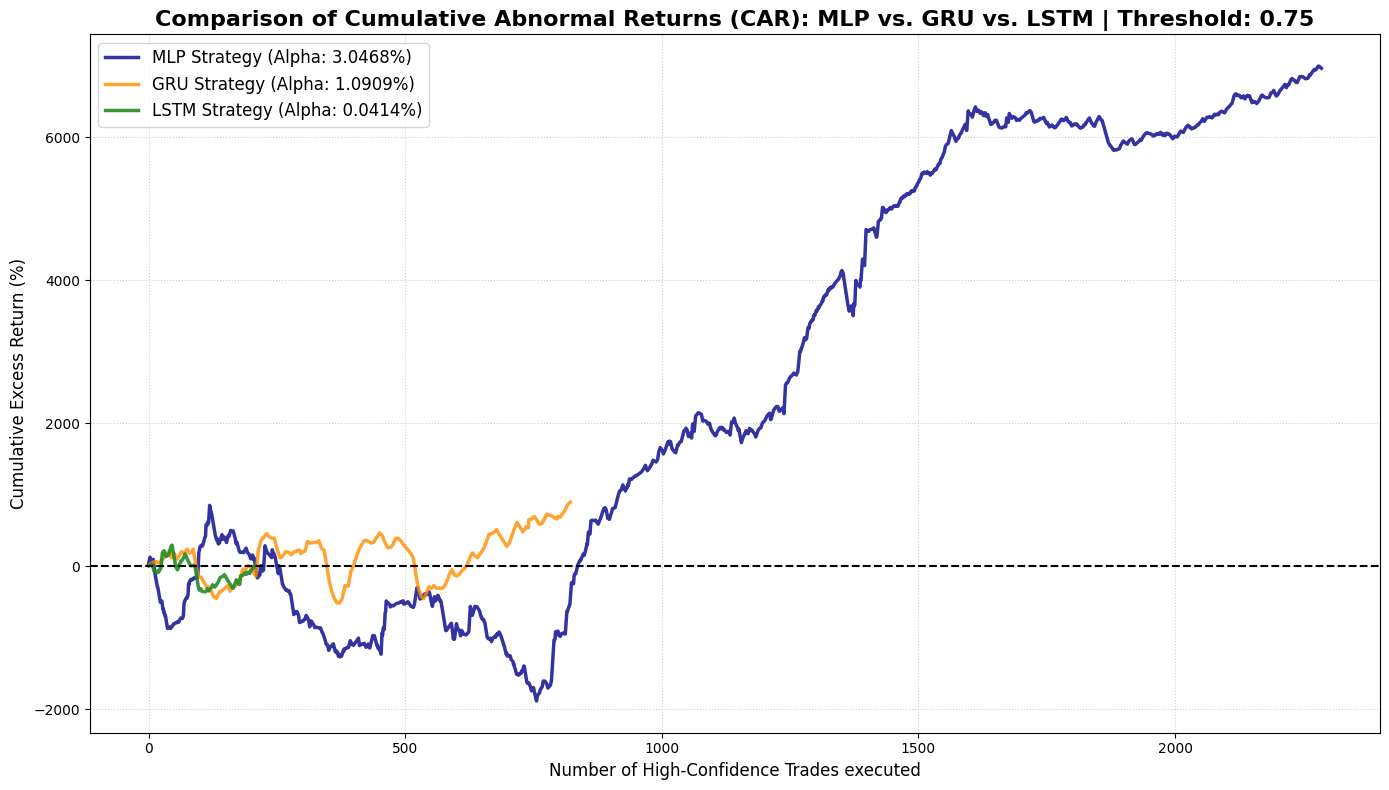

In [74]:
# ==============================================================================
# 7. FINAL COMPARISON & PLOTS (MLP vs GRU vs LSTM)
# ==============================================================================

# 1. SET THRESHOLD AND RECALCULATE (To ensure we are using 0.75)
threshold = 0.75 

# Recalculate MLP
mlp_high_conf = results_df[results_df['Insider_Influence_Signal'] >= threshold].sort_index().copy()
mlp_alpha = mlp_high_conf['Actual_Return'].mean() if not mlp_high_conf.empty else 0
mlp_high_conf['CAR'] = mlp_high_conf['Actual_Return'].cumsum()

# Recalculate GRU
gru_high_conf_robust = gru_results_robust[gru_results_robust['Insider_Influence_Signal'] >= threshold].copy()
robust_alpha = gru_high_conf_robust['Actual_Return'].mean() if not gru_high_conf_robust.empty else 0
gru_high_conf_robust['CAR'] = gru_high_conf_robust['Actual_Return'].cumsum()

# Recalculate LSTM
lstm_high_conf_robust = lstm_results_robust[lstm_results_robust['Insider_Influence_Signal'] >= threshold].copy()
lstm_alpha = lstm_high_conf_robust['Actual_Return'].mean() if not lstm_high_conf_robust.empty else 0
lstm_high_conf_robust['CAR'] = lstm_high_conf_robust['Actual_Return'].cumsum()

# 2. PRINT THE COMPARISON TABLE
print(f"\n--- FINAL MODEL COMPARISON: MLP VS GRU VS LSTM (Threshold: {threshold}) ---")
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'Directional Accuracy (%)', 'Jensen\'s Alpha (%)', 'High-Confidence Trades'],
    'MLP (Baseline)': [
        mae, 
        hit_rate * 100, 
        mlp_alpha, 
        len(mlp_high_conf)
    ],
    'GRU (Robust)': [
        mean_absolute_error(y_test_3d, gru_preds_robust), 
        gru_dir_acc, 
        robust_alpha, 
        len(gru_high_conf_robust)
    ],
    'LSTM (Robust)': [
        mean_absolute_error(y_test_3d, lstm_preds_robust), 
        lstm_dir_acc, 
        lstm_alpha, 
        len(lstm_high_conf_robust)
    ]
})
print(comparison_df.to_string(index=False))

# 3. PLOT THE GRAPH
plt.figure(figsize=(14, 8))

# Plot all three models
if not mlp_high_conf.empty:
    plt.plot(mlp_high_conf['CAR'].values, label=f'MLP Strategy (Alpha: {mlp_alpha:.4f}%)', color='darkblue', lw=2.5, alpha=0.8)
    
if not gru_high_conf_robust.empty:
    plt.plot(gru_high_conf_robust['CAR'].values, label=f'GRU Strategy (Alpha: {robust_alpha:.4f}%)', color='darkorange', lw=2.5, alpha=0.8)

if not lstm_high_conf_robust.empty:
    plt.plot(lstm_high_conf_robust['CAR'].values, label=f'LSTM Strategy (Alpha: {lstm_alpha:.4f}%)', color='forestgreen', lw=2.5, alpha=0.9)

# Use dynamic f-string to ensure the title always reflects the threshold variable
plt.title(f'Comparison of Cumulative Abnormal Returns (CAR): MLP vs. GRU vs. LSTM | Threshold: {threshold}', fontsize=16, fontweight='bold')
plt.xlabel('Number of High-Confidence Trades executed', fontsize=12)
plt.ylabel('Cumulative Excess Return (%)', fontsize=12)
plt.axhline(0, color='black', lw=1.5, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()


EVALUATING THRESHOLD: 0.5

--- FINAL MODEL COMPARISON (THRESHOLD = 0.5) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        1.348735      2.067770       1.450972
  High-Confidence Trades     7893.000000   7171.000000    6045.000000




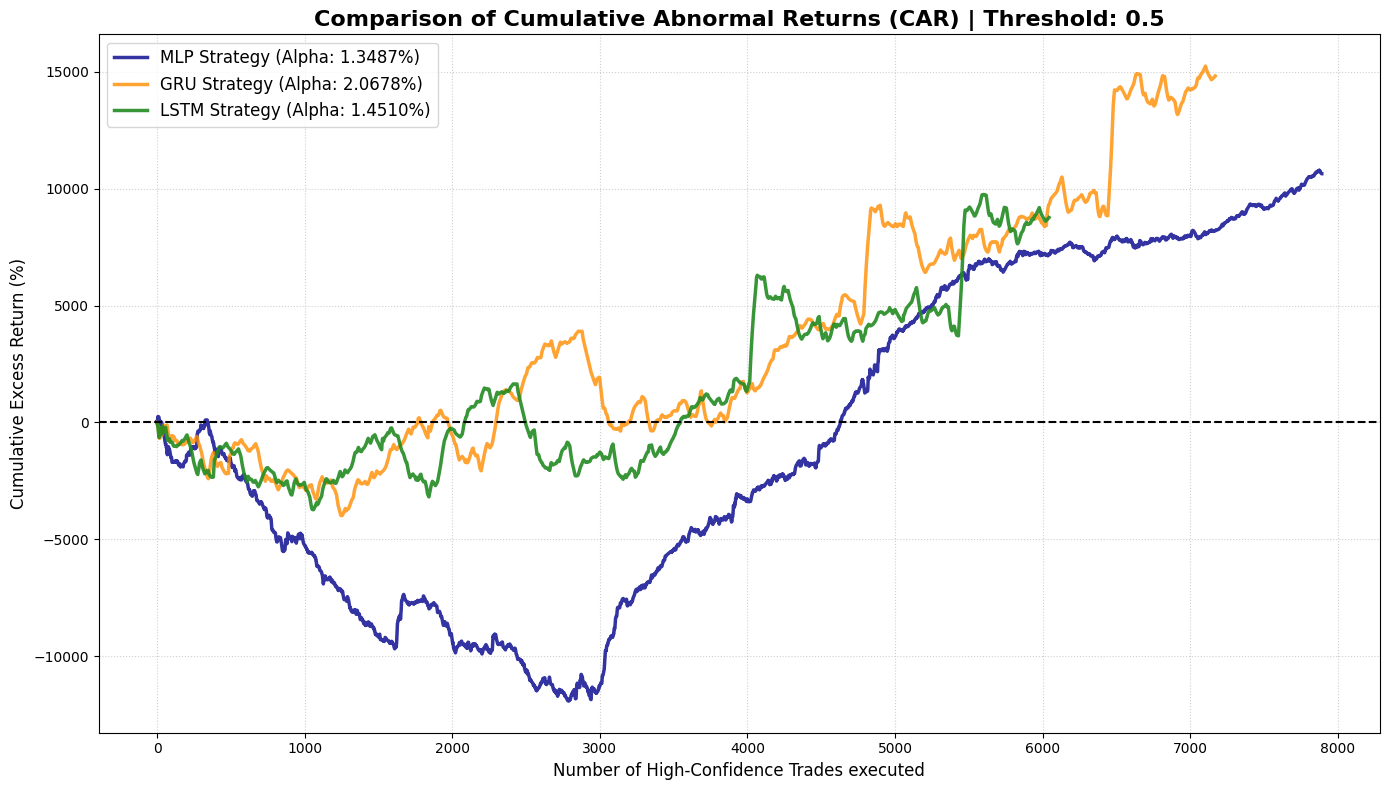


EVALUATING THRESHOLD: 0.55

--- FINAL MODEL COMPARISON (THRESHOLD = 0.55) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        1.472220      1.381451       1.333485
  High-Confidence Trades     6902.000000   6062.000000    5306.000000




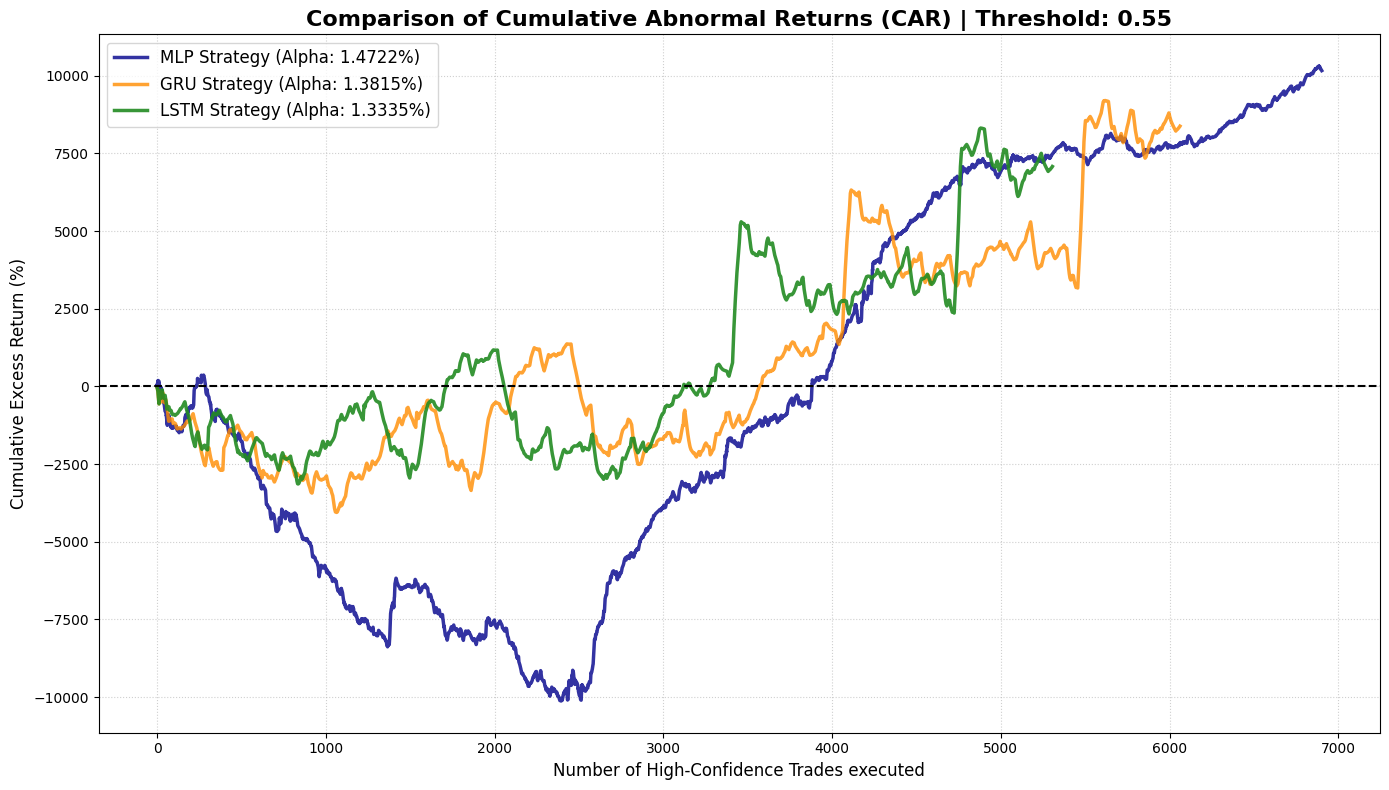


EVALUATING THRESHOLD: 0.6

--- FINAL MODEL COMPARISON (THRESHOLD = 0.6) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        1.737842      1.336628       0.333496
  High-Confidence Trades     5359.000000   5954.000000    2219.000000




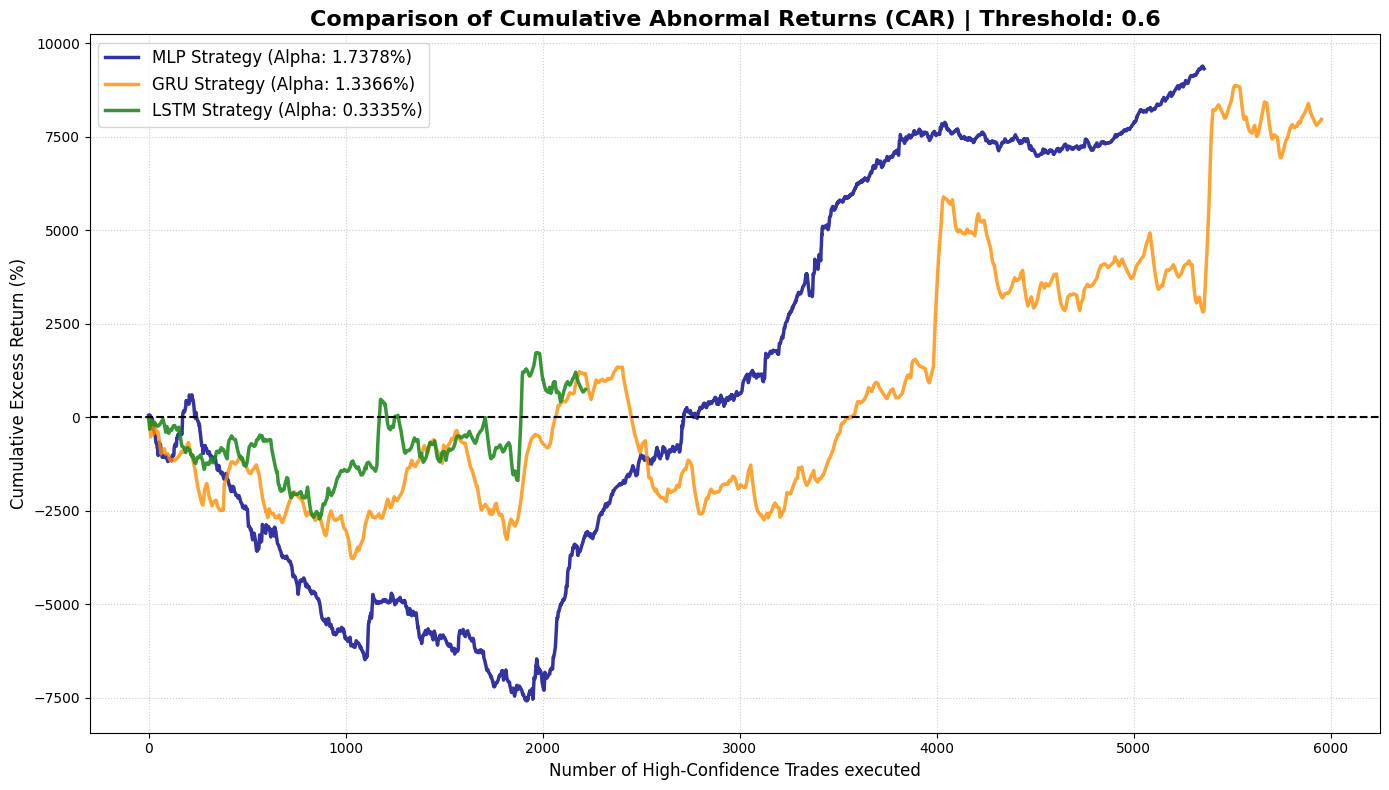


EVALUATING THRESHOLD: 0.65

--- FINAL MODEL COMPARISON (THRESHOLD = 0.65) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        2.239340      1.086187       0.677932
  High-Confidence Trades     4007.000000    842.000000     940.000000




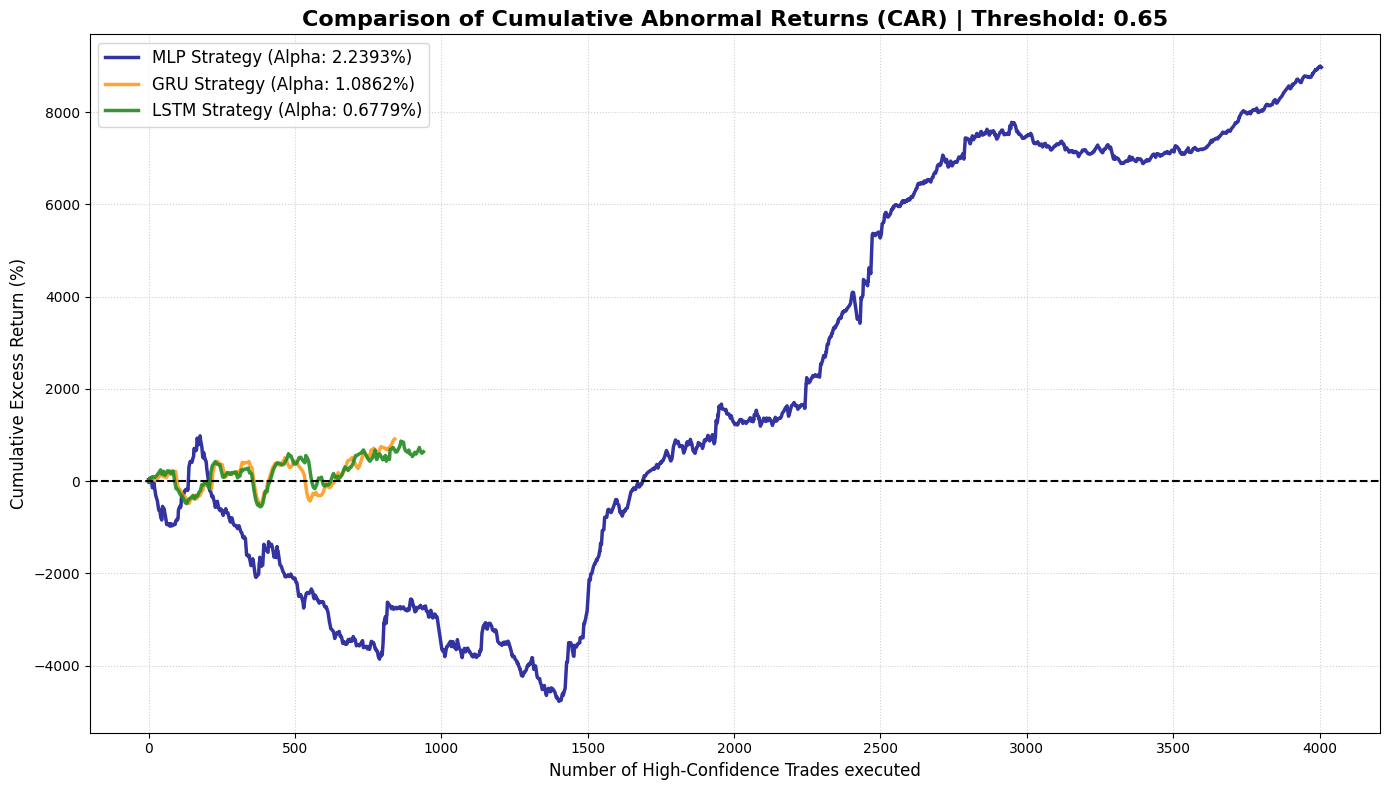


EVALUATING THRESHOLD: 0.7

--- FINAL MODEL COMPARISON (THRESHOLD = 0.7) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        2.235059      1.115946       1.006345
  High-Confidence Trades     3134.000000    834.000000     697.000000




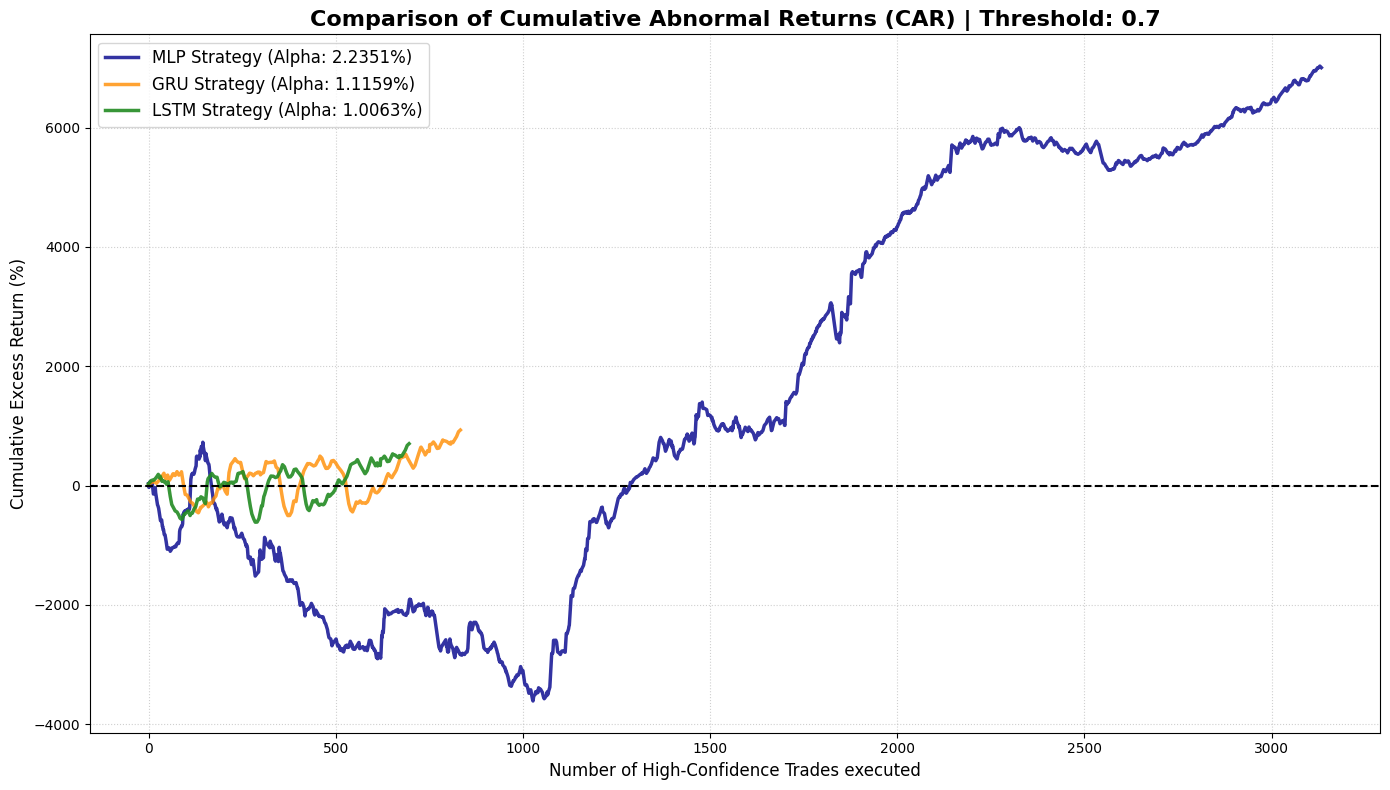


EVALUATING THRESHOLD: 0.8

--- FINAL MODEL COMPARISON (THRESHOLD = 0.8) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        1.622058      5.754073      -3.286804
  High-Confidence Trades     1507.000000      5.000000      32.000000




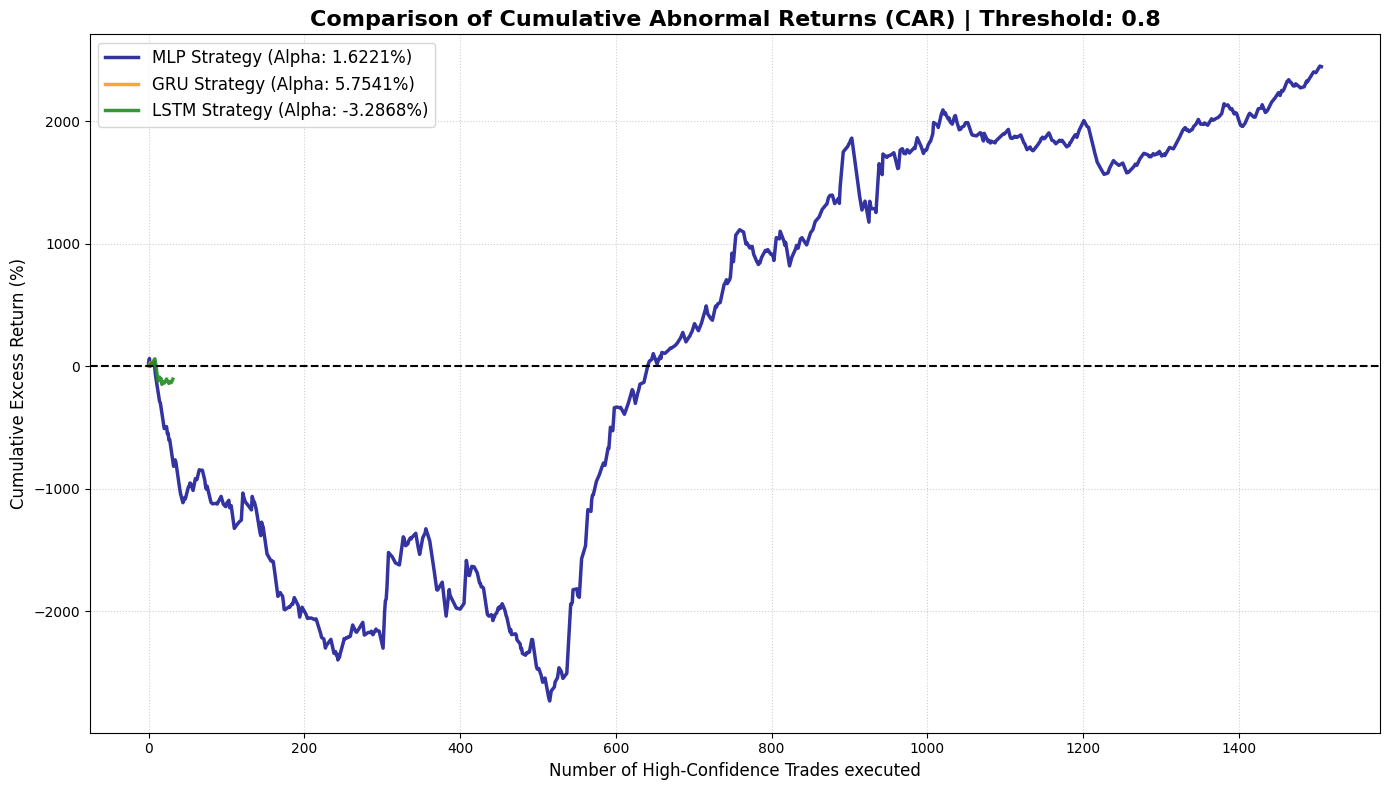


EVALUATING THRESHOLD: 0.85

--- FINAL MODEL COMPARISON (THRESHOLD = 0.85) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        2.042847      9.084907     -17.272932
  High-Confidence Trades     1255.000000      3.000000       5.000000




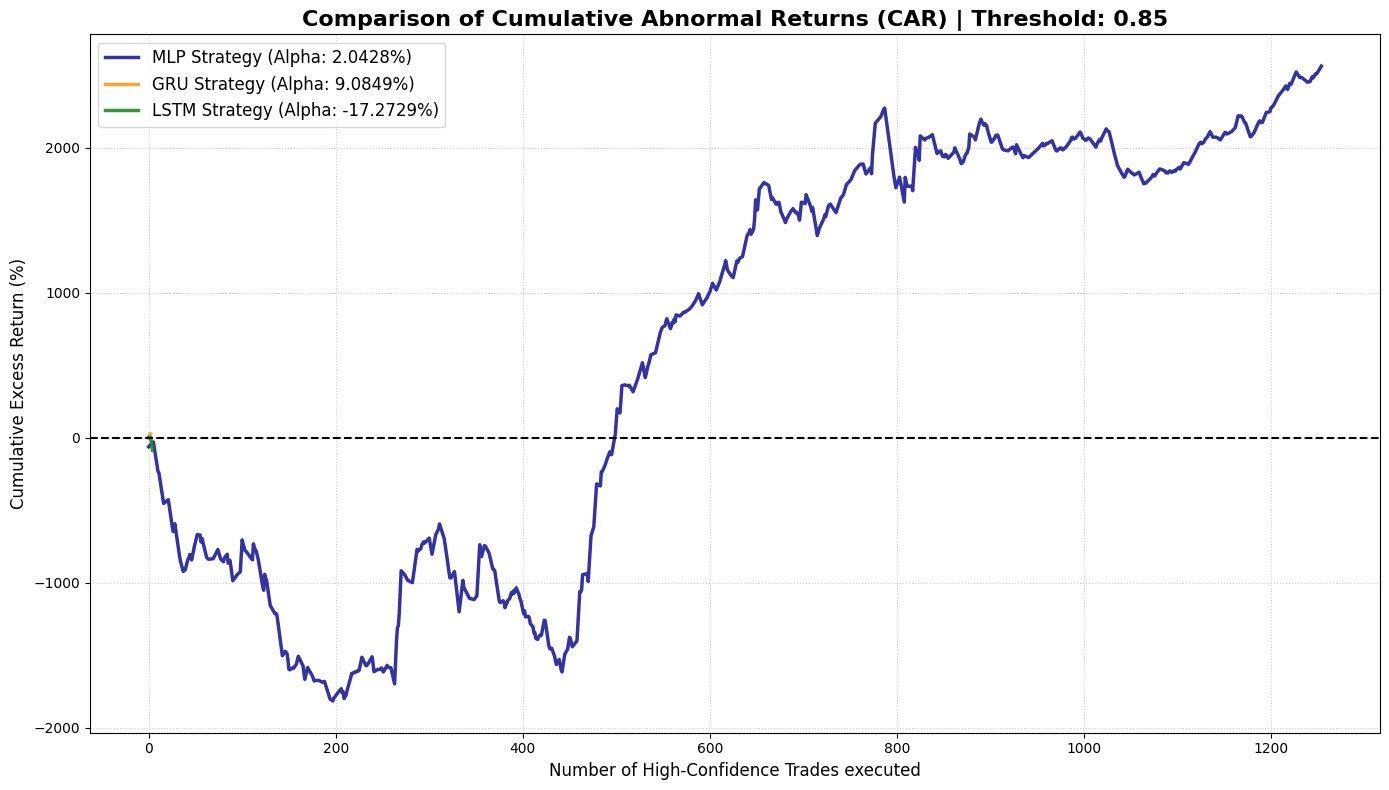


EVALUATING THRESHOLD: 0.9

--- FINAL MODEL COMPARISON (THRESHOLD = 0.9) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        1.763137      0.000000     -10.273441
  High-Confidence Trades      249.000000      0.000000       4.000000




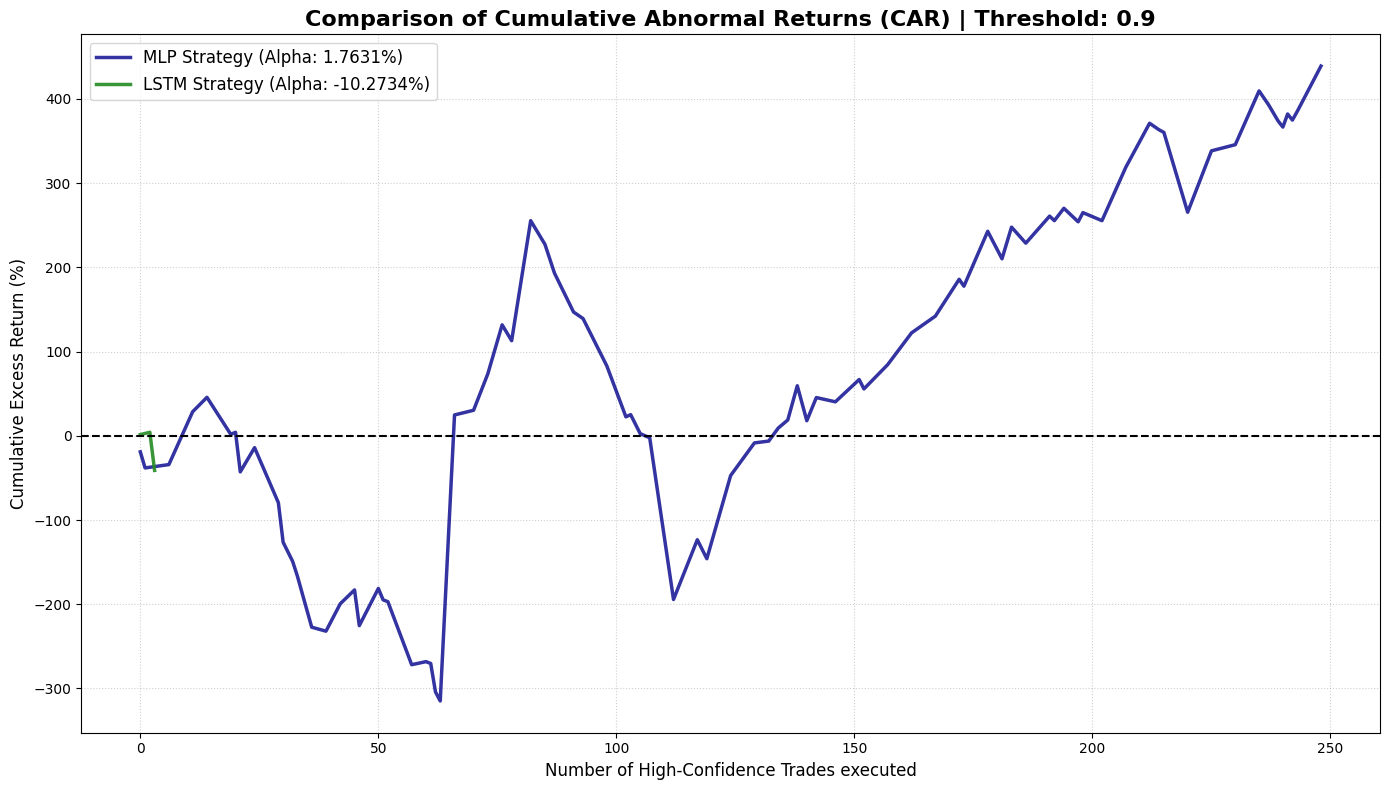


EVALUATING THRESHOLD: 0.95

--- FINAL MODEL COMPARISON (THRESHOLD = 0.95) ---
                  Metric  MLP (Baseline)  GRU (Robust)  LSTM (Robust)
                     MAE       18.066976     16.964905      16.568497
Directional Accuracy (%)       51.706381     44.687341      44.687341
      Jensen's Alpha (%)        1.805960      0.000000       1.392377
  High-Confidence Trades      191.000000      0.000000       2.000000




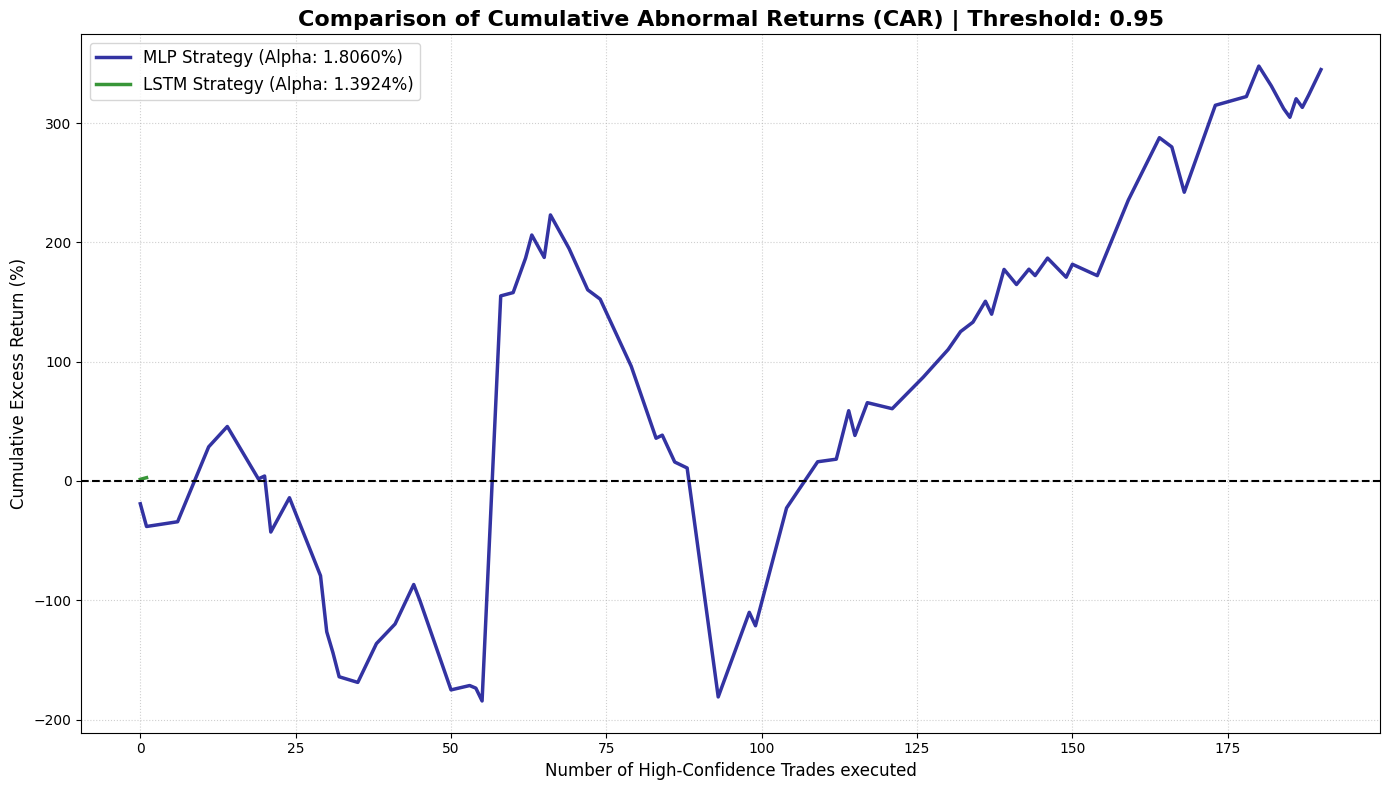

In [76]:
# ==============================================================================
# SENSITIVITY ANALYSIS: MULTIPLE THRESHOLDS
# ==============================================================================

# Define the list of thresholds to evaluate (excluding the 0.75 baseline)
threshold_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.85, 0.9, 0.95]

for thr in threshold_list:
    print(f"\n" + "="*80)
    print(f"EVALUATING THRESHOLD: {thr}")
    print("="*80 + "\n")
    
    # 1. Recalculate MLP
    mlp_high_conf = results_df[results_df['Insider_Influence_Signal'] >= thr].sort_index().copy()
    mlp_alpha = mlp_high_conf['Actual_Return'].mean() if not mlp_high_conf.empty else 0
    mlp_high_conf['CAR'] = mlp_high_conf['Actual_Return'].cumsum()

    # 2. Recalculate GRU
    gru_high_conf_robust = gru_results_robust[gru_results_robust['Insider_Influence_Signal'] >= thr].copy()
    robust_alpha = gru_high_conf_robust['Actual_Return'].mean() if not gru_high_conf_robust.empty else 0
    gru_high_conf_robust['CAR'] = gru_high_conf_robust['Actual_Return'].cumsum()

    # 3. Recalculate LSTM
    lstm_high_conf_robust = lstm_results_robust[lstm_results_robust['Insider_Influence_Signal'] >= thr].copy()
    lstm_alpha = lstm_high_conf_robust['Actual_Return'].mean() if not lstm_high_conf_robust.empty else 0
    lstm_high_conf_robust['CAR'] = lstm_high_conf_robust['Actual_Return'].cumsum()

    # Print Comparison Table
    print(f"--- FINAL MODEL COMPARISON (THRESHOLD = {thr}) ---")
    comparison_df = pd.DataFrame({
        'Metric': ['MAE', 'Directional Accuracy (%)', 'Jensen\'s Alpha (%)', 'High-Confidence Trades'],
        'MLP (Baseline)': [
            mae, 
            hit_rate * 100, 
            mlp_alpha, 
            len(mlp_high_conf)
        ],
        'GRU (Robust)': [
            mean_absolute_error(y_test_3d, gru_preds_robust), 
            gru_dir_acc, 
            robust_alpha, 
            len(gru_high_conf_robust)
        ],
        'LSTM (Robust)': [
            mean_absolute_error(y_test_3d, lstm_preds_robust), 
            lstm_dir_acc, 
            lstm_alpha, 
            len(lstm_high_conf_robust)
        ]
    })
    print(comparison_df.to_string(index=False))
    print("\n")

    # Plot the graph for the current threshold
    plt.figure(figsize=(14, 8))

    # We use if-statements to ensure we don't try to plot empty datasets (e.g., at threshold 0.95)
    if not mlp_high_conf.empty:
        plt.plot(mlp_high_conf['CAR'].values, label=f'MLP Strategy (Alpha: {mlp_alpha:.4f}%)', color='darkblue', lw=2.5, alpha=0.8)
        
    if not gru_high_conf_robust.empty:
        plt.plot(gru_high_conf_robust['CAR'].values, label=f'GRU Strategy (Alpha: {robust_alpha:.4f}%)', color='darkorange', lw=2.5, alpha=0.8)

    if not lstm_high_conf_robust.empty:
        plt.plot(lstm_high_conf_robust['CAR'].values, label=f'LSTM Strategy (Alpha: {lstm_alpha:.4f}%)', color='forestgreen', lw=2.5, alpha=0.9)

    plt.title(f'Comparison of Cumulative Abnormal Returns (CAR) | Threshold: {thr}', fontsize=16, fontweight='bold')
    plt.xlabel('Number of High-Confidence Trades executed', fontsize=12)
    plt.ylabel('Cumulative Excess Return (%)', fontsize=12)
    plt.axhline(0, color='black', lw=1.5, linestyle='--')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

# Advanced Sequence Modeling: The Prediction Error vs. Economic Utility Paradox
In evaluating the recurrent architectures against the baseline, the results reveal a striking paradox within financial machine learning: models optimized for the lowest predictive error do not necessarily generate the highest economic utility.

When minimizing the Mean Absolute Error (MAE) through Bayesian optimization (Optuna), the Long Short-Term Memory (LSTM) network successfully achieved the lowest prediction error of all models (16.57). This can be attributed to the LSTM's dual-state architecture. While the GRU relies on a single hidden state, the LSTM utilizes an additional independent cell state, allowing it to maintain long-term memory across historical trade sequences.

However, this superior memory mechanism caused the LSTM to become hyper-conservative. By successfully learning that financial time-series data is inherently noisy, the LSTM minimized its MAE by consistently predicting returns very close to zero. Consequently, when subjected to the execution threshold of 0.75, the LSTM suffered from severe "signal starvation." It was too risk-averse to generate actionable signals, executing only 207 trades and yielding a negligible Jensen's Alpha of 0.04%. The GRU served as a middle ground, executing 823 trades for a 1.09% Alpha, but ultimately, the structurally simpler baseline Multi-layer Perceptron (MLP) drastically outperformed both recurrent models in risk-adjusted excess returns. The MLP's willingness to make aggressive directional predictions, despite a higher MAE (18.07), allowed it to capitalize on the underlying trading edge, generating a highly significant Alpha of 3.05% over 2,286 trades.

# Sensitivity Analysis and the Optimal Execution Threshold

To evaluate the robust execution of these strategies, a sensitivity analysis was conducted across signal thresholds ranging from 0.50 to 0.95. The analysis demonstrated that identifying the correct execution threshold is as critical as the model architecture itself.

At a lower threshold of 0.50, the MLP executed nearly 7,000 trades. However, this lack of selectivity exposed the strategy to extreme market noise, resulting in a catastrophic initial drawdown of nearly -7,500% in cumulative excess return. In a real-world scenario, a fund executing this strategy would face insolvency long before capturing the eventual recovery. Conversely, pushing the threshold beyond 0.80 caused complete signal starvation across all models, essentially halting trading activity.

The baseline threshold of 0.75 emerged as the undisputed optimal filter. At this level, the MLP successfully eliminated low-conviction, high-risk signals. It bypassed the severe drawdown phase entirely, smoothing the equity curve while retaining enough trade volume (2,286 executions) to allow the "law of large numbers" to realize the strategy's statistical edge.

# Macroeconomic Regime Shifts and Micro-Signal Vulnerability
Despite the impressive 3.05% Alpha generated by the optimized MLP, visual analysis of the Cumulative Abnormal Returns (CAR) across broader threshold tests reveals periods of sharp, synchronized contractions. Regardless of the underlying mathematical architecture, aggressive trading volume exposes the strategies to severe drawdowns before initiating recoveries.

This highlights a fundamental limitation of insider-influence tracking: the vulnerability of micro-indicators to macroeconomic regime shifts. During broad market sell-offs driven by external headwinds—such as systemic interest rate hikes or inflationary pressures—the predictive power of a specific lawmaker's stock purchase is temporarily neutralized. Even if a politician possesses advantageous legislative foresight regarding a specific company, that individual stock remains subject to the gravitational pull of a collapsing broader market.

# Final Conclusions and Model Utility
This project successfully proves that congressional insider trading activity contains a quantifiable, exploitable statistical edge. However, it also exposes the strict limitations of deploying these models as standalone trading systems.

### The Best Performing Model: 
The MLP is the clear winner. By avoiding the overfitting and hyper-conservatism that plagued the LSTM and GRU, the MLP demonstrated that simpler, highly aggressive models paired with strict confidence thresholds (0.75) are better suited for capturing directional anomalies in noisy financial data.

### Critique of the Strategy: 
While a 3.05% Jensen's Alpha is highly significant, relying purely on individual insider trades is inherently dangerous. The models are entirely blind to the macroeconomic context. A standalone bot trading exclusively on these signals would struggle to survive a severe bear market.

### Real-World Application: 
These models should not be used as isolated, automated trading systems. Instead, their true utility lies in serving as alpha-generating indicators within a broader quantitative portfolio. By combining this Insider-Influence Signal with macroeconomic trend filters and strict risk management overlays, institutional investors could effectively utilize this methodology to tilt their portfolios toward historically informed, high-conviction assets.

In [77]:
# ==============================================================================
# 8. EXPORT TO BACKEND DATABASE (MVP SCHEMA)
# ==============================================================================

# We will export the predictions from the top-performing model (MLP)
# First, we need to map back to the original test_df to get the 'Ticker' and 'Traded' dates
export_df = pd.DataFrame(index=results_df.index)

# Retrieve the required fields from the original test_df using the matching index
export_df['Ticker'] = test_df.loc[results_df.index, 'Ticker']
export_df['As-of-Date'] = test_df.loc[results_df.index, 'Traded']

# Convert the 0.0 - 1.0 Insider Influence Signal to the requested 0 - 100 Score
export_df['Score (0-100)'] = (results_df['Insider_Influence_Signal'] * 100).astype(int)

# Convert the data-driven Confidence score (0.1 - 1.0) to the requested 0 - 5 scale
export_df['Confidence (0-5)'] = (results_df['Confidence_Score_Raw'] * 5).round(1)

# Clean up the dataframe (remove any NaNs just in case) and sort by date
export_df = export_df.dropna(subset=['Ticker', 'As-of-Date']).sort_values(by='As-of-Date')

# Save to CSV for the Backend team / Database ingestion
export_filename = 'backend_insider_scores_mvp.csv'
export_df.to_csv(export_filename, index=False)

print(f"\n--- BACKEND EXPORT COMPLETE ---")
print(f"Successfully exported {len(export_df)} scores to '{export_filename}'.")
display(export_df.head())


--- BACKEND EXPORT COMPLETE ---
Successfully exported 9904 scores to 'backend_insider_scores_mvp.csv'.


,Ticker,As-of-Date,Score (0-100),Confidence (0-5)
0,890.0,2025-08-07,37,0.8
12,1637.0,2025-08-07,85,4.5
11,394.0,2025-08-07,77,5.0
10,394.0,2025-08-07,77,5.0
9,394.0,2025-08-07,82,5.0
